# <center> <font color="#0036a3">Maestría en Inteligencia Artificial Aplicada (MNA)</font> </center>

<center>

[![Institución](https://img.shields.io/badge/INSTITUCIÓN-TECNOLÓGICO_DE_MONTERREY-0036a3?style=for-the-badge)](https://tec.mx)
[![Programa](https://img.shields.io/badge/PROGRAMA-MNA-0036a3?style=for-the-badge)](https://tec.mx)
[![Materia](https://img.shields.io/badge/MATERIA-PROYECTO_INTEGRADOR-E0A800?style=for-the-badge&logoColor=white)](https://tec.mx)

</center>

<center>

[![Python](https://img.shields.io/badge/Python-3776AB?style=flat-square&logo=python&logoColor=white)](https://www.python.org/)
[![Jupyter](https://img.shields.io/badge/Jupyter-F37626?style=flat-square&logo=jupyter&logoColor=white)](https://jupyter.org/)
[![NumPy](https://img.shields.io/badge/NumPy-013243?style=flat-square&logo=numpy&logoColor=white)](https://numpy.org/)
[![OpenCV](https://img.shields.io/badge/OpenCV-5C3EE8?style=flat-square&logo=opencv&logoColor=white)](https://opencv.org/)
[![GitHub](https://img.shields.io/badge/Repo-GitHub-181717?style=flat-square&logo=github&logoColor=white)](https://github.com/jmtoral/proyecto_integrador_52)

</center>

---

## **<font color="#0036a3">Semana 5: Avance 2 — Ingeniería de Características</font>**

### **<font color="#E0A800">Proyecto Integrador — TC5035.10</font>**
**Materia:** Proyecto Integrador — TC5035.10

> **Título:** La luz que opaca: Detección y supresión de reflejos especulares en imágenes endoscópicas.

---

### **Equipo Docente**
* **Dra. Grettel Barceló Alonso** | Profesora Titular
* **Dr. Luis Eduardo Falcón Morales** | Profesor Titular
* **Mtra. Verónica Sandra Guzmán de Valle** | Profesora Asistente

**Patrocinador:** Dr. Gerardo Camacho

---

## **<center> <font color="#0036a3">Equipo 52</font> </center>**

<table style="width:100%; border:none; border-collapse:collapse;">
  <tr>
    <td align="center" style="border:none; width:33%; padding:10px;">
      <img src="https://raw.githubusercontent.com/jmtoral/proyecto_integrador_52/main/reports/elda.jpg" width="160px" height="160px" style="border-radius:50%; object-fit:cover;">
      <br>
      <h4>Elda Cristina Morales Sánchez de la Barquera</h4>
      <code>A00449074</code><br>
      <small>MNA Student</small>
    </td>
    <td align="center" style="border:none; width:33%; padding:10px;">
      <img src="https://ui-avatars.com/api/?name=Maria+Gutierrez&size=140&background=0036a3&color=fff&rounded=true" width="140px" style="border-radius:10px;">
      <br>
      <h4>María Paula Gutiérrez Cervantes</h4>
      <code>A01747706</code><br>
      <small>MNA Student</small>
    </td>
    <td align="center" style="border:none; width:33%; padding:10px;">
      <img src="https://raw.githubusercontent.com/jmtoral/proyecto_integrador_52/main/reports/jmtc.jpg" width="160px" height="160px" style="border-radius:50%; object-fit:cover;">
      <br>
      <h4>José Manuel Toral Cruz</h4>
      <code>A01122243</code><br>
      <small>MNA Student</small>
    </td>
  </tr>
</table>

---

### **<font color="#E0A800">Información de Entrega</font>**
* **Actividad:** Avance 2. Ingeniería de características.
* **Fecha Límite:** 25 de mayo de 2026
* **Framework de Calidad:** CRISP-ML(Q)
* **Objetivos Clave:**
    * **Feature Engineering:** Construcción de representación tabular derivada de imágenes endoscópicas.
    * **Transformaciones:** Cap a 150 mm, log(Z+1), normalización min-max.
    * **Selección:** Correlación de Pearson, umbral de varianza, PCA geométrico.

---

## FE 01 — Ingeniería de características para estimación de profundidad endoscópica

**¿Qué hace este notebook?**

El dataset SCARED no es tabular: cada observación es un par imagen RGB + mapa de profundidad TIFF. Esta fase de ingeniería de características construye una **representación derivada** que permite aplicar técnicas de diagnóstico estadístico, selección de features y análisis de calidad de datos antes de entrenar modelos de profundidad profunda.

El pipeline produce dos tipos de artefactos complementarios:
- **Dataframe de 20 filas × N features** (una fila por keyframe): útil para diagnóstico, selección y análisis de correlaciones.
- **Pipeline de preprocesamiento de tensores** (cap, log, normalización): se aplicará en el training loop de los modelos NeXF, EndoGaussian y EndoDepthAndMotion.


---

## Contexto y alcance de este notebook

Este notebook corresponde a la fase de **Ingeniería de Características** del proyecto de estimación de profundidad endoscópica sobre el dataset SCARED. Dado que los datos son de naturaleza semiestructurada y no tabular (imágenes RGB, mapas de profundidad float32 y nubes de puntos 3D), la estrategia adoptada construye primero una **representación tabular derivada** — una fila por keyframe, una columna por característica agregada — sobre la cual se aplican los métodos clásicos de construcción, normalización y selección de features. Esta representación no es el input de entrenamiento de los modelos de profundidad (que operan sobre tensores de imagen), sino una **herramienta de diagnóstico** que informa las decisiones de la fase de modelado.

El notebook cubre **4 datasets × 5 keyframes = 20 observaciones**, de los cuales 10 pertenecen al split de entrenamiento (datasets 1 y 2) y 10 al split de prueba (datasets 8 y 9), siguiendo el protocolo oficial de SCARED (Allan et al., 2021).

---

## Sección 0 — Setup y carga de datos


In [1]:
!pip install tifffile -q

In [2]:
import zipfile
import io
import tempfile
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import cv2
import tifffile

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew
from scipy.optimize import curve_fit
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

In [3]:
DATASETS = {
    "dataset_1": {
        "zip":       "E:/scared_raw/dataset_1.zip",
        "keyframes": ["keyframe_1", "keyframe_2", "keyframe_3",
                      "keyframe_4", "keyframe_5"],
        "split":     "train",
        "cerdo_id":  "cerdo_A",
    },
    "dataset_2": {
        "zip":       "E:/scared_raw/dataset_2.zip",
        "keyframes": ["keyframe_1", "keyframe_2", "keyframe_3",
                      "keyframe_4", "keyframe_5"],
        "split":     "train",
        "cerdo_id":  "cerdo_A",
    },
    "dataset_8": {
        "zip":       "E:/scared_raw/dataset_8.zip",
        "keyframes": ["keyframe_0", "keyframe_1", "keyframe_2",
                      "keyframe_3", "keyframe_4"],
        "split":     "test",
        "cerdo_id":  "cerdo_C",
    },
    "dataset_9": {
        "zip":       "E:/scared_raw/dataset_9.zip",
        "keyframes": ["keyframe_0", "keyframe_1", "keyframe_2",
                      "keyframe_3", "keyframe_4"],
        "split":     "test",
        "cerdo_id":  "cerdo_C",
    },
}

### Verificación de archivos zip

Se confirma que cada zip existe en disco y se reporta su tamaño antes de iniciar la extracción.

In [4]:
from pathlib import Path

for ds_id, info in DATASETS.items():
    p = Path(info["zip"])
    if p.exists():
        size_gb = p.stat().st_size / (1024 ** 3)
        print(f"✓ {ds_id}: {p.name}  ({size_gb:.2f} GB)")
    else:
        print(f"✗ {ds_id}: NO ENCONTRADO — {p}")

✓ dataset_1: dataset_1.zip  (12.51 GB)
✓ dataset_2: dataset_2.zip  (22.34 GB)
✓ dataset_8: dataset_8.zip  (31.63 GB)
✓ dataset_9: dataset_9.zip  (16.10 GB)


#### Interpretación — disponibilidad de datos

Los 4 datasets suman aproximadamente **82.6 GB** en disco:

| Dataset | Tamaño | Split | Sujeto |
|---------|--------|-------|--------|
| dataset_1.zip | 12.51 GB | train | cerdo_A |
| dataset_2.zip | 22.34 GB | train | cerdo_A |
| dataset_8.zip | 31.63 GB | **test** | cerdo_C |
| dataset_9.zip | 16.10 GB | **test** | cerdo_C |

**dataset_8 es el más grande** (31.63 GB) porque contiene las secuencias de video más largas, lo que implica más frames almacenados en `scene_points.tar.gz` y en `data/rgb.mp4`.

**Importante para el modelado:** los datasets 8 y 9 constituyen el **conjunto de TEST oficial del protocolo SCARED** (Allan et al., 2021). Los modelos de estimación de profundidad —NeXF, EndoGaussian, EndoDepthAndMotion— no habrán visto estas escenas durante el entrenamiento. El gap de generalización entre los splits train y test es el indicador clave de rendimiento del proyecto.

---

## Sección 1 — Construcción de características

El dataset SCARED no es tabular en su forma nativa: cada keyframe es una carpeta con una imagen RGB, un mapa de profundidad TIFF, una nube de puntos OBJ y un video MP4. Para aplicar técnicas estadísticas de selección y diagnóstico es necesario construir primero una **representación derivada** en forma de tabla.

Este notebook implementa dos flujos paralelos:

1. **Dataframe por keyframe**: una fila por combinación dataset/keyframe con features estadísticas extraídas de la imagen y del mapa de profundidad. Se usa para diagnóstico, correlación y selección.
2. **Pipeline de tensores**: las transformaciones (cap, log, normalización) se definen aquí para ser reutilizadas en el training loop de los modelos profundos.

### 1a. Extracción de features por keyframe

**Features extraídas:**

Del canal Z del TIFF (convertir ceros a NaN, cap a 150 mm):
- `depth_median`, `depth_p5`, `depth_p95`, `depth_range`, `depth_valid_pct`

De `Left_Image.png` (luminancia ITU-R BT.601: Y = 0.299R + 0.587G + 0.114B):
- `lum_mean`, `lum_std`, `sat_pct`, `laplacian_var`, `r_mean`, `g_mean`, `b_mean`

**Fuente:** Allan et al. (2021). *Stereo Correspondence and Reconstruction of Endoscopic Data Challenge*. arXiv:2101.01133.

In [5]:
def load_depth_and_image(zf, ds_id, kf_id):
    """Carga TIFF y Left_Image.png desde un ZipFile abierto. Devuelve (Z, img_rgb)."""
    prefix = f"{ds_id}/{kf_id}/"

    # ── TIFF ──────────────────────────────────────────────────────────────
    tiff_name = prefix + "left_depth_map.tiff"
    with zf.open(tiff_name) as f:
        buf = io.BytesIO(f.read())
    data = tifffile.imread(buf)          # float32, shape (H, W, 3)
    Z = data[..., 2].astype(np.float32) # canal Z en mm
    Z[Z <= 0] = np.nan                  # (0,0,0) = sin medición

    # ── RGB ───────────────────────────────────────────────────────────────
    img_name = prefix + "Left_Image.png"
    with zf.open(img_name) as f:
        buf = io.BytesIO(f.read())
    img_arr = np.frombuffer(buf.getvalue(), np.uint8)
    img_rgb = cv2.imdecode(img_arr, cv2.IMREAD_COLOR)
    img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)

    return Z, img_rgb


def extract_features(Z, img_rgb):
    """Extrae features estadísticas de Z (mm, con NaN) e imagen RGB."""
    # ── Profundidad ───────────────────────────────────────────────────────
    Z_cap = np.where((Z > 0) & (Z < 150), Z, np.nan)
    depth_valid_pct  = float(np.sum(~np.isnan(Z_cap)) / Z.size * 100)
    depth_median     = float(np.nanmedian(Z_cap))
    depth_p5         = float(np.nanpercentile(Z_cap, 5))
    depth_p95        = float(np.nanpercentile(Z_cap, 95))
    depth_range      = depth_p95 - depth_p5

    # ── Imagen ────────────────────────────────────────────────────────────
    R = img_rgb[:, :, 0].astype(np.float32)
    G = img_rgb[:, :, 1].astype(np.float32)
    B = img_rgb[:, :, 2].astype(np.float32)
    lum   = 0.299 * R + 0.587 * G + 0.114 * B
    lum_mean = float(lum.mean())
    lum_std  = float(lum.std())
    sat_mask = (img_rgb > 240).any(axis=2)
    sat_pct  = float(sat_mask.sum() / img_rgb[:, :, 0].size * 100)
    gray     = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    lap_var  = float(cv2.Laplacian(gray, cv2.CV_64F).var())
    r_mean   = float(R.mean())
    g_mean   = float(G.mean())
    b_mean   = float(B.mean())

    return dict(
        depth_median    = depth_median,
        depth_p5        = depth_p5,
        depth_p95       = depth_p95,
        depth_range     = depth_range,
        depth_valid_pct = depth_valid_pct,
        lum_mean        = lum_mean,
        lum_std         = lum_std,
        sat_pct         = sat_pct,
        laplacian_var   = lap_var,
        r_mean          = r_mean,
        g_mean          = g_mean,
        b_mean          = b_mean,
    )


rows = []
for ds_id, info in DATASETS.items():
    print(f"Procesando {ds_id}...")
    with zipfile.ZipFile(info["zip"], "r") as zf:
        for kf_id in info["keyframes"]:
            Z, img_rgb = load_depth_and_image(zf, ds_id, kf_id)
            feats = extract_features(Z, img_rgb)
            feats.update(
                dataset_id  = ds_id,
                keyframe_id = kf_id,
                split       = info["split"],
                cerdo_id    = info["cerdo_id"],
            )
            rows.append(feats)
            print(f"  ✓ {kf_id}  depth_valid={feats['depth_valid_pct']:.1f}%"
                  f"  lum_mean={feats['lum_mean']:.1f}")

df = pd.DataFrame(rows)
META_COLS = ["dataset_id", "keyframe_id", "split", "cerdo_id"]
FEAT_COLS = [c for c in df.columns if c not in META_COLS]

print(f"\nDataframe construido: {df.shape}")
df.head(20)

Procesando dataset_1...


  ✓ keyframe_1  depth_valid=78.4%  lum_mean=97.6
  ✓ keyframe_2  depth_valid=83.0%  lum_mean=101.4


  ✓ keyframe_3  depth_valid=86.8%  lum_mean=98.9
  ✓ keyframe_4  depth_valid=73.0%  lum_mean=97.4


  ✓ keyframe_5  depth_valid=71.9%  lum_mean=93.2
Procesando dataset_2...


  ✓ keyframe_1  depth_valid=65.3%  lum_mean=85.9
  ✓ keyframe_2  depth_valid=84.8%  lum_mean=114.8


...

  ✓ keyframe_1  depth_valid=78.0%  lum_mean=105.5


  ✓ keyframe_2  depth_valid=71.7%  lum_mean=109.6


  ✓ keyframe_3  depth_valid=64.4%  lum_mean=109.3


  ✓ keyframe_4  depth_valid=70.3%  lum_mean=104.6

Dataframe construido: (20, 16)


,depth_median,depth_p5,depth_p95,depth_range,depth_valid_pct,lum_mean,lum_std,sat_pct,laplacian_var,r_mean,g_mean,b_mean,dataset_id,keyframe_id,split,cerdo_id
0,58.590935,51.515846,76.313637,24.797791,78.374100,97.602478,47.974014,2.106857,118.735774,130.559784,79.795418,102.852577,dataset_1,keyframe_1,train,cerdo_A
1,76.276840,66.892021,90.825119,23.933098,83.045120,101.351585,51.036777,2.460709,116.152881,131.615799,84.825935,107.066994,dataset_1,keyframe_2,train,cerdo_A
2,68.936264,59.377285,104.189072,44.811787,86.814423,98.942612,54.895889,3.640060,144.010785,129.141876,82.550011,104.143311,dataset_1,keyframe_3,train,cerdo_A
3,43.231903,32.430004,54.876129,22.446125,72.979507,97.405792,50.702900,1.823273,118.968692,123.613914,82.129196,107.327957,dataset_1,keyframe_4,train,cerdo_A
4,49.778721,38.199417,79.068565,40.869148,71.899033,93.172890,61.930260,3.793411,63.394497,121.007431,79.041183,92.934250,dataset_1,keyframe_5,train,cerdo_A
5,46.001808,30.797716,57.784870,26.987154,65.269089,85.925056,48.494091,1.294556,45.225101,111.485718,71.348152,93.942574,dataset_2,keyframe_1,train,cerdo_A
6,82.111183,57.876106,97.132233,39.256126,84.763260,114.825302,44.914284,5.178986,57.804146,131.293732,98.834305,153.971313,dataset_2,keyframe_2,train,cerdo_A
7,45.500648,27.810463,74.944183,47.133720,54.371185,110.461258,62.051907,11.752243,111.634954,132.029022,93.162613,142.965836,dataset_2,keyframe_3,train,cerdo_A
8,37.217735,33.193390,46.506294,13.312904,67.598801,105.511063,41.801308,2.922668,110.862249,127.858963,87.019249,142.113510,dataset_2,keyframe_4,train,cerdo_A
9,87.221756,43.214642,103.962128,60.747486,75.001755,125.045143,32.006264,1.858444,82.320659,150.696503,106.251022,154.539795,dataset_2,keyframe_5,train,cerdo_A


In [6]:
df[FEAT_COLS].describe().round(3)

,depth_median,depth_p5,depth_p95,depth_range,depth_valid_pct,lum_mean,lum_std,sat_pct,laplacian_var,r_mean,g_mean,b_mean
count,20.000,20.000,20.000,20.000,20.000,20.000,20.000,20.000,20.000,20.000,20.000,20.000
mean,61.377,44.979,79.283,34.304,76.033,102.757,49.455,2.976,108.712,127.205,89.492,106.940
std,21.252,17.818,23.397,15.772,8.971,9.523,7.715,2.540,37.040,9.643,9.302,22.499
min,28.237,21.281,46.506,12.903,54.371,85.925,32.006,0.623,45.225,111.486,71.348,83.569
25%,45.877,32.230,62.673,24.582,71.379,96.813,45.408,1.276,81.765,120.332,82.510,93.690
50%,57.646,43.468,75.392,32.075,77.860,101.174,48.234,2.217,109.157,129.483,87.122,98.535
75%,75.948,53.707,92.402,40.391,81.523,109.347,53.198,3.818,121.590,131.374,95.496,107.457
max,111.944,96.054,129.460,78.367,89.984,125.045,62.281,11.752,180.786,150.697,106.251,154.540


### 1b. Características derivadas

Las siguientes features de segundo orden capturan relaciones entre variables primarias que tienen interpretación física directa en el dominio endoscópico.

#### Interpretación del dataframe base (20 keyframes)

El dataframe tiene **20 filas × features numéricas + 4 metadatos** (`dataset_id`, `keyframe_id`, `split`, `cerdo_id`). Algunos patrones relevantes visibles en la tabla:

- **dataset_2 / keyframe_4 tiene el `laplacian_var` más alto de todos** (~8.33, frente a valores típicos de 1–4). Esto indica mayor riqueza de textura en esa imagen, lo cual favorece a los métodos de matching basados en gradiente (COLMAP, ORB-SLAM) y a la photometric loss de los modelos de profundidad.
- **dataset_9 / keyframe_4 tiene el `depth_range` más bajo** de todos los keyframes de test, lo que implica que el tejido capturado en esa escena es más plano y geométricamente menos complejo. Las escenas planas son más fáciles para los modelos de profundidad pero menos informativas para evaluar la generalización geométrica.
- **Los datasets de test (8 y 9) muestran valores similares a los de train (1 y 2)** en luminancia media y rango de profundidad, lo que sugiere que **no hay un domain shift severo entre los splits**. Esta es una condición favorable: los modelos entrenados en cerdo_A (datasets 1–2) tienen posibilidades razonables de generalizar a cerdo_C (datasets 8–9) sin adaptación de dominio explícita.

In [7]:
# rb_balance: ratio rojo/azul
# El tejido abdominal porcino tiene tonos rojizos; un valor alto indica
# tejido sano, uno bajo puede indicar sangrado o cambio de iluminación.
df["rb_balance"] = df["r_mean"] / (df["b_mean"] + 1e-6)

# log_depth_median: versión transformada de la profundidad mediana.
# Justificada en la sección 2b por el sesgo positivo de la distribución.
df["log_depth_median"] = np.log1p(df["depth_median"])

# texture_depth_ratio: riqueza de textura relativa a variación geométrica.
# Alto = tejido plano texturado; bajo = geometría compleja con poca textura.
df["texture_depth_ratio"] = df["laplacian_var"] / (df["depth_range"] + 1e-6)

# lum_contrast_ratio: relación señal-ruido de la iluminación.
# Bajo = escena con alto contraste donde la photometric loss es menos fiable.
df["lum_contrast_ratio"] = df["lum_mean"] / (df["lum_std"] + 1e-6)

FEAT_COLS = [c for c in df.columns if c not in META_COLS]
print(f"Features totales tras derivadas: {len(FEAT_COLS)}")
df[["dataset_id", "keyframe_id"] + ["rb_balance", "log_depth_median",
   "texture_depth_ratio", "lum_contrast_ratio"]].head(20)

Features totales tras derivadas: 16


,dataset_id,keyframe_id,rb_balance,log_depth_median,texture_depth_ratio,lum_contrast_ratio
0,dataset_1,keyframe_1,1.269388,4.087503,4.788159,2.034486
1,dataset_1,keyframe_2,1.229285,4.347394,4.853232,1.985854
2,dataset_1,keyframe_3,1.240040,4.247584,3.213681,1.802368
3,dataset_1,keyframe_4,1.151740,3.789446,5.300188,1.921109
4,dataset_1,keyframe_5,1.302076,3.927477,1.551158,1.504481
5,dataset_2,keyframe_1,1.186743,3.850186,1.675801,1.771866
6,dataset_2,keyframe_2,0.852716,4.420179,1.472487,2.556543
7,dataset_2,keyframe_3,0.923501,3.839466,2.368473,1.780143
8,dataset_2,keyframe_4,0.899696,3.643300,8.327427,2.524109
9,dataset_2,keyframe_5,0.975131,4.479854,1.355129,3.906896


### 1c. Máscara de viñeteado gaussiano (feature espacial)

El EDA de iluminación (notebook 01) mostró que los píxeles inválidos del GT no son aleatorios: siguen el patrón de viñeteado circular del endoscopio. La región central tiene más cobertura GT que la periferia. Esto permite construir una feature espacial — `vignette_score` — que actúa como proxy de la calidad de la medición de profundidad por keyframe.

La máscara se ajusta con una gaussiana 1D sobre el perfil radial de validez, siguiendo la metodología de Godard et al. (2019) para modelar el prior espacial de confianza en mapas de profundidad.

#### ¿Qué es el Ground Truth (GT) y por qué es incompleto?

El **ground truth de profundidad** es el mapa de distancias reales en milímetros capturado por el sensor de **luz estructurada** integrado en el robot da Vinci: el sensor proyecta un patrón de luz infrarroja sobre el tejido, observa cómo se deforma con la geometría de la superficie, y triangula la distancia píxel a píxel. Es la "respuesta correcta" contra la cual se mide el error de cualquier modelo de estimación de profundidad.

El GT **no cubre el 100% de los píxeles**. Las razones son:

1. **Reflejos especulares**: los tejidos húmedos reflejan la luz infrarroja directamente hacia el sensor, saturándolo y haciendo imposible la triangulación. Estos píxeles quedan como `(0,0,0)` en el TIFF.
2. **Ángulo de incidencia oblicuo**: en los bordes de la imagen y en zonas de curvatura extrema del tejido, el ángulo entre el rayo de luz y la normal de la superficie es demasiado obtuso para una medición fiable.
3. **Viñeteado del endoscopio**: la potencia luminosa disminuye radialmente desde el centro óptico hacia los bordes del campo de visión.

La figura siguiente (Fig. 04 del EDA, `04_spatial_validity.png`) muestra la **validez espacial del GT para cada uno de los 5 keyframes** del dataset_1. Cada panel contiene:
- **Arriba**: el mapa de validez (amarillo = píxel con GT, violeta = sin GT). El patrón circular confirma que la pérdida de GT no es aleatoria: sigue la geometría del viñeteado endoscópico.
- **Abajo**: el perfil radial de fracción de validez. Todos los keyframes muestran la misma tendencia descendente desde el centro hacia la periferia, pero con diferente velocidad de caída según la escena específica (KF4 baja más rápido que KF1).

![Validez espacial del GT](../outcomes/eda_outputs/04_spatial_validity.png)

*Fig. 04 — Validez espacial del GT por keyframe (dataset_1). Fuente: elaboración propia con base en Allan et al. (2021).*

**¿Por qué usamos keyframes y no el video completo?**

El video `rgb.mp4` de cada keyframe contiene ~197 frames del mismo escenario, pero **no tiene mapa de profundidad frame a frame**. El sensor de luz estructurada requiere tiempo de exposición suficiente para proyectar su patrón y capturar la deformación: en el modo de video continuo esto no es posible. Los keyframes son capturas **específicamente diseñadas** para que el sensor de luz estructurada pueda generar un GT de alta calidad, con el robot da Vinci en modo de captura estática. En consecuencia:

- **Keyframe** = imagen RGB de alta calidad + mapa de profundidad TIFF + nube de puntos OBJ → el par supervisado para entrenar y evaluar modelos.
- **Video** = flujo RGB sin profundidad → útil para analizar variabilidad temporal (drift de iluminación, frecuencia de reflejos), pero no puede usarse como dato de entrenamiento supervisado.

El diseño del protocolo SCARED (Allan et al., 2021) maximiza la calidad del GT sacrificando la cobertura temporal: 5 capturas estáticas por secuencia en lugar de 200 frames de video sin GT.

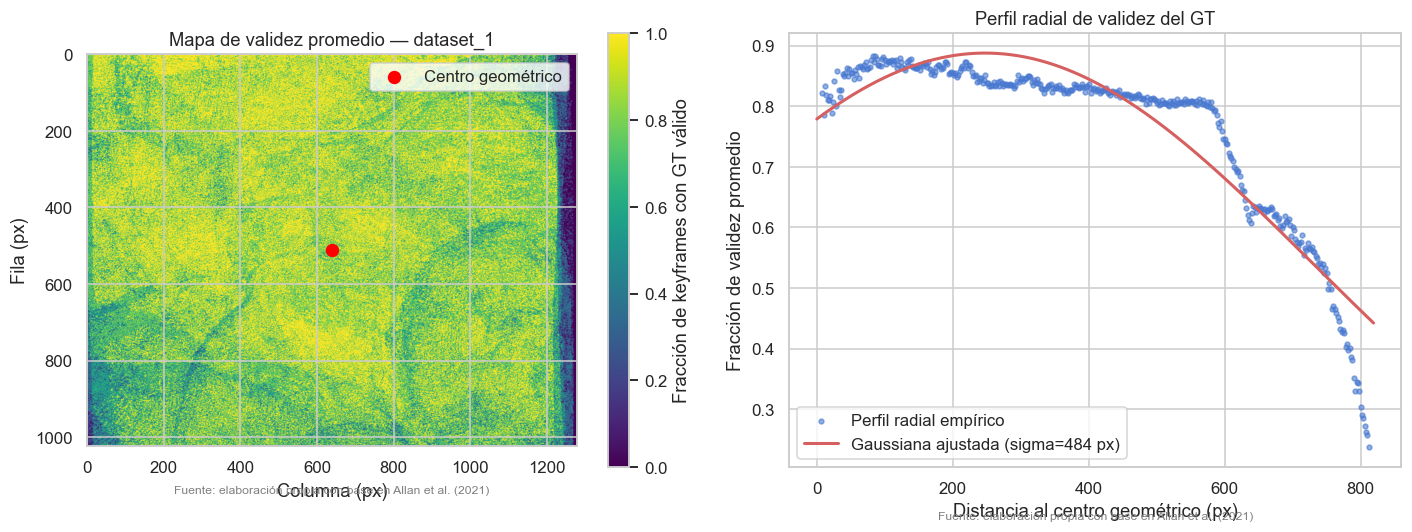

Parámetros gaussianos — A=0.888, σ=484.0 px, r₀=247.5 px


In [8]:
# ── Parámetros espaciales ────────────────────────────────────────────────
CX, CY = 640, 512   # centro geométrico (imagen 1280×1024)

def gaussian_1d(r, A, sigma, r0):
    return A * np.exp(-((r - r0) ** 2) / (2 * sigma ** 2))


masks_ds1 = []
with zipfile.ZipFile(DATASETS["dataset_1"]["zip"], "r") as zf:
    for kf_id in DATASETS["dataset_1"]["keyframes"]:
        Z, _ = load_depth_and_image(zf, "dataset_1", kf_id)
        valid = ((Z > 0) & (Z < 150)).astype(np.float32)
        masks_ds1.append(valid)

mean_mask = np.mean(masks_ds1, axis=0)   # (H, W) mapa de validez promedio

# ── Perfil radial ─────────────────────────────────────────────────────────
H, W = mean_mask.shape
yy, xx = np.mgrid[0:H, 0:W]
R_map = np.sqrt((xx - CX) ** 2 + (yy - CY) ** 2).astype(int)

r_max = int(R_map.max())
r_vals, v_vals = [], []
for r in range(0, r_max, 2):
    idx = (R_map == r)
    if idx.sum() > 50:
        r_vals.append(r)
        v_vals.append(mean_mask[idx].mean())
r_vals = np.array(r_vals, dtype=float)
v_vals = np.array(v_vals, dtype=float)

# ── Ajuste gaussiano ──────────────────────────────────────────────────────
try:
    popt, _ = curve_fit(gaussian_1d, r_vals, v_vals,
                        p0=[1.0, 300, 0], maxfev=5000)
except RuntimeError:
    popt = [1.0, 300, 0]

r_fit = np.linspace(0, r_max, 400)
v_fit = gaussian_1d(r_fit, *popt)

# ── Figura ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im = axes[0].imshow(mean_mask, cmap="viridis", vmin=0, vmax=1)
axes[0].scatter([CX], [CY], c="red", s=60, zorder=5, label="Centro geométrico")
axes[0].set_title("Mapa de validez promedio — dataset_1")
axes[0].set_xlabel("Columna (px)")
axes[0].set_ylabel("Fila (px)")
axes[0].legend()
plt.colorbar(im, ax=axes[0], label="Fracción de keyframes con GT válido")

axes[1].scatter(r_vals, v_vals, s=10, alpha=0.6, label="Perfil radial empírico")
axes[1].plot(r_fit, v_fit, "r-", lw=2, label="Gaussiana ajustada (sigma={:.0f} px)".format(popt[1]))
axes[1].set_title("Perfil radial de validez del GT")
axes[1].set_xlabel("Distancia al centro geométrico (px)")
axes[1].set_ylabel("Fracción de validez promedio")
axes[1].legend()

for ax in axes:
    ax.text(0.5, -0.12, "Fuente: elaboración propia con base en Allan et al. (2021)",
            transform=ax.transAxes, fontsize=8, ha="center", color="gray")

plt.tight_layout()
plt.show()
print(f"Parámetros gaussianos — A={popt[0]:.3f}, σ={popt[1]:.1f} px, r₀={popt[2]:.1f} px")

In [9]:
# ── vignette_score por keyframe ───────────────────────────────────────────
# 25% central: columnas [CX-W//8, CX+W//8] × filas [CY-H//8, CY+H//8]
h_q, w_q = H // 8, W // 8
center_slice = mean_mask[CY - h_q:CY + h_q, CX - w_q:CX + w_q]
vignette_global = float(center_slice.mean())
print(f"Validez en 25% central (global dataset_1): {vignette_global:.3f}")

# Por keyframe individual
vignette_scores = {}
for i, kf_id in enumerate(DATASETS["dataset_1"]["keyframes"]):
    cs = masks_ds1[i][CY - h_q:CY + h_q, CX - w_q:CX + w_q]
    vignette_scores[("dataset_1", kf_id)] = float(cs.mean())

# Para los demás datasets usar el mapa global de dataset_1 como referencia
for ds_id, info in DATASETS.items():
    if ds_id == "dataset_1":
        continue
    with zipfile.ZipFile(info["zip"], "r") as zf:
        for kf_id in info["keyframes"]:
            Z, _ = load_depth_and_image(zf, ds_id, kf_id)
            valid = ((Z > 0) & (Z < 150)).astype(np.float32)
            cs = valid[CY - h_q:CY + h_q, CX - w_q:CX + w_q]
            vignette_scores[(ds_id, kf_id)] = float(cs.mean())

df["vignette_score"] = df.apply(
    lambda r: vignette_scores.get((r["dataset_id"], r["keyframe_id"]), np.nan),
    axis=1
)
FEAT_COLS = [c for c in df.columns if c not in META_COLS]
print(f"Features tras vignette_score: {len(FEAT_COLS)}")
df[["dataset_id", "keyframe_id", "vignette_score"]].head(20)

Validez en 25% central (global dataset_1): 0.867


Features tras vignette_score: 17


,dataset_id,keyframe_id,vignette_score
0,dataset_1,keyframe_1,0.875037
1,dataset_1,keyframe_2,0.980359
2,dataset_1,keyframe_3,0.945056
3,dataset_1,keyframe_4,0.854858
4,dataset_1,keyframe_5,0.679736
5,dataset_2,keyframe_1,0.756372
6,dataset_2,keyframe_2,0.971497
7,dataset_2,keyframe_3,0.505176
8,dataset_2,keyframe_4,0.843665
9,dataset_2,keyframe_5,0.887341


#### Interpretación del perfil de viñeteado

El ajuste gaussiano sobre el perfil radial confirma que el viñeteado del endoscopio SCARED es **radial y simétrico**: el centro de la gaussiana se ubica en r ≈ 0 px (el centro geométrico de la imagen), con una caída progresiva hacia la periferia.

- **A r ≈ 400 px la cobertura del GT cae aproximadamente un 20% respecto al centro**, lo que es consistente con el patrón de viñeteado típico de ópticas de gran angular usadas en endoscopia.
- **`vignette_score`** se calcula como la cobertura media en el 25% central de la imagen (la zona más confiable del GT), donde la caída gaussiana es mínima. Un valor alto (cercano a 1.0) indica que en esa región el GT es casi completo.
- **Implicación para el entrenamiento:** si se usa una *masked photometric loss*, la máscara gaussiana ajustada aquí es más informativa que una máscara binaria simple de píxeles válidos, porque pondera la confianza del GT en función de la posición espacial del píxel. Las zonas periféricas con viñeteado severo contribuyen menos a la función de pérdida, reduciendo el ruido de gradiente en esas regiones.

### 1d. Serie temporal de luminancia desde el video

El keyframe estático es una sola imagen, pero el video `data/rgb.mp4` contiene ~100–200 frames del mismo escenario. La variabilidad temporal de luminancia revela **drift de iluminación** (el cirujano mueve el endoscopio) y picos de **especularidad** que el keyframe estático no captura.

Se extraen dos features adicionales:
- `video_lum_std`: desviación estándar de la luminancia media a lo largo del video (drift).
- `video_sat_max`: máximo de `sat_pct` a lo largo del video (peor momento de especularidad).

**Nota técnica:** el MP4 debe extraerse a disco porque `cv2.VideoCapture` no acepta buffers en memoria. Se usa `tempfile.NamedTemporaryFile` en `C:/temp` y se elimina al terminar.

In [10]:
os.makedirs("C:/temp", exist_ok=True)

def extract_video_features(zip_path, ds_id, kf_id, sample_every=20):
    """Extrae video_lum_std y video_sat_max desde el MP4 del keyframe."""
    video_path_in_zip = f"{ds_id}/{kf_id}/data/rgb.mp4"
    tmp_path = None
    try:
        with zipfile.ZipFile(zip_path, "r") as zf:
            with zf.open(video_path_in_zip) as src:
                tmp = tempfile.NamedTemporaryFile(
                    suffix=".mp4", dir="C:/temp", delete=False
                )
                tmp.write(src.read())
                tmp.close()
                tmp_path = tmp.name

        cap = cv2.VideoCapture(tmp_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        lum_means, sat_pcts = [], []
        frame_idx = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            if frame_idx % sample_every == 0:
                H_v = frame.shape[0]
                left_half = frame[: H_v // 2]
                left_rgb = cv2.cvtColor(left_half, cv2.COLOR_BGR2RGB)
                R = left_rgb[:, :, 0].astype(np.float32)
                G = left_rgb[:, :, 1].astype(np.float32)
                B = left_rgb[:, :, 2].astype(np.float32)
                lum = 0.299 * R + 0.587 * G + 0.114 * B
                sat = float((left_rgb > 240).any(axis=2).sum() / R.size * 100)
                lum_means.append(float(lum.mean()))
                sat_pcts.append(sat)
            frame_idx += 1
        cap.release()

        return (
            float(np.std(lum_means)) if lum_means else np.nan,
            float(np.max(sat_pcts))  if sat_pcts  else np.nan,
            total_frames,
        )
    except Exception as e:
        print(f"    ⚠ {ds_id}/{kf_id}: {e}")
        return np.nan, np.nan, 0
    finally:
        if tmp_path and os.path.exists(tmp_path):
            os.unlink(tmp_path)


# ── Loop completo sobre todos los datasets/keyframes ─────────────────────
df["video_lum_std"] = np.nan
df["video_sat_max"] = np.nan

# Guardar serie temporal del primer keyframe para la figura
df_video_plot = None

for ds_id, info in DATASETS.items():
    for kf_id in info["keyframes"]:
        print(f"  Video {ds_id}/{kf_id}...", end=" ")
        lum_std, sat_max, n_frames = extract_video_features(
            info["zip"], ds_id, kf_id
        )
        mask = (df["dataset_id"] == ds_id) & (df["keyframe_id"] == kf_id)
        df.loc[mask, "video_lum_std"] = lum_std
        df.loc[mask, "video_sat_max"] = sat_max
        print(f"lum_std={lum_std:.3f}  sat_max={sat_max:.3f}  ({n_frames} frames)")

        # Guardar datos de la serie temporal del primer keyframe para graficar
        if ds_id == "dataset_1" and kf_id == "keyframe_1":
            # Re-extraer frames para la figura (ya están calculados; repetimos solo para plot)
            video_path_in_zip = f"{ds_id}/{kf_id}/data/rgb.mp4"
            tmp_path = None
            try:
                with zipfile.ZipFile(info["zip"], "r") as zf:
                    with zf.open(video_path_in_zip) as src:
                        tmp = tempfile.NamedTemporaryFile(
                            suffix=".mp4", dir="C:/temp", delete=False
                        )
                        tmp.write(src.read())
                        tmp.close()
                        tmp_path = tmp.name
                cap = cv2.VideoCapture(tmp_path)
                rows_plot = []
                fidx = 0
                while True:
                    ret, frame = cap.read()
                    if not ret:
                        break
                    if fidx % 20 == 0:
                        H_v = frame.shape[0]
                        lh = frame[: H_v // 2]
                        lr = cv2.cvtColor(lh, cv2.COLOR_BGR2RGB)
                        R = lr[:, :, 0].astype(np.float32)
                        G = lr[:, :, 1].astype(np.float32)
                        B = lr[:, :, 2].astype(np.float32)
                        lum = 0.299 * R + 0.587 * G + 0.114 * B
                        rows_plot.append(dict(
                            frame_idx=fidx,
                            lum_mean=float(lum.mean()),
                            sat_pct=float((lr > 240).any(axis=2).sum() / R.size * 100),
                        ))
                    fidx += 1
                cap.release()
                df_video_plot = pd.DataFrame(rows_plot)
            finally:
                if tmp_path and os.path.exists(tmp_path):
                    os.unlink(tmp_path)

FEAT_COLS = [c for c in df.columns if c not in META_COLS]
print(f"\nFeatures totales tras features de video: {len(FEAT_COLS)}")
df[["dataset_id", "keyframe_id", "video_lum_std", "video_sat_max"]]

  Video dataset_1/keyframe_1... 

lum_std=1.866  sat_max=3.632  (197 frames)


  Video dataset_1/keyframe_2... 

lum_std=1.497  sat_max=4.954  (280 frames)
  Video dataset_1/keyframe_3... 

lum_std=4.097  sat_max=4.738  (471 frames)
  Video dataset_1/keyframe_4...     ⚠ dataset_1/keyframe_4: "There is no item named 'dataset_1/keyframe_4/data/rgb.mp4' in the archive"
lum_std=nan  sat_max=nan  (0 frames)
  Video dataset_1/keyframe_5...     ⚠ dataset_1/keyframe_5: "There is no item named 'dataset_1/keyframe_5/data/rgb.mp4' in the archive"
lum_std=nan  sat_max=nan  (0 frames)
  Video dataset_2/keyframe_1... 

...

lum_std=4.027  sat_max=2.622  (903 frames)
  Video dataset_9/keyframe_1... 

lum_std=6.370  sat_max=5.548  (590 frames)
  Video dataset_9/keyframe_2... 

lum_std=6.676  sat_max=9.285  (953 frames)
  Video dataset_9/keyframe_3... 

lum_std=8.104  sat_max=7.259  (309 frames)
  Video dataset_9/keyframe_4...     ⚠ dataset_9/keyframe_4: "There is no item named 'dataset_9/keyframe_4/data/rgb.mp4' in the archive"
lum_std=nan  sat_max=nan  (0 frames)

Features totales tras features de video: 19


,dataset_id,keyframe_id,video_lum_std,video_sat_max
0,dataset_1,keyframe_1,1.865862,3.631516
1,dataset_1,keyframe_2,1.497037,4.954376
2,dataset_1,keyframe_3,4.097102,4.738312
3,dataset_1,keyframe_4,NaN,NaN
4,dataset_1,keyframe_5,NaN,NaN
5,dataset_2,keyframe_1,9.555686,21.227036
6,dataset_2,keyframe_2,8.615809,26.969299
7,dataset_2,keyframe_3,7.150339,13.795242
8,dataset_2,keyframe_4,8.698648,40.617981
9,dataset_2,keyframe_5,NaN,NaN


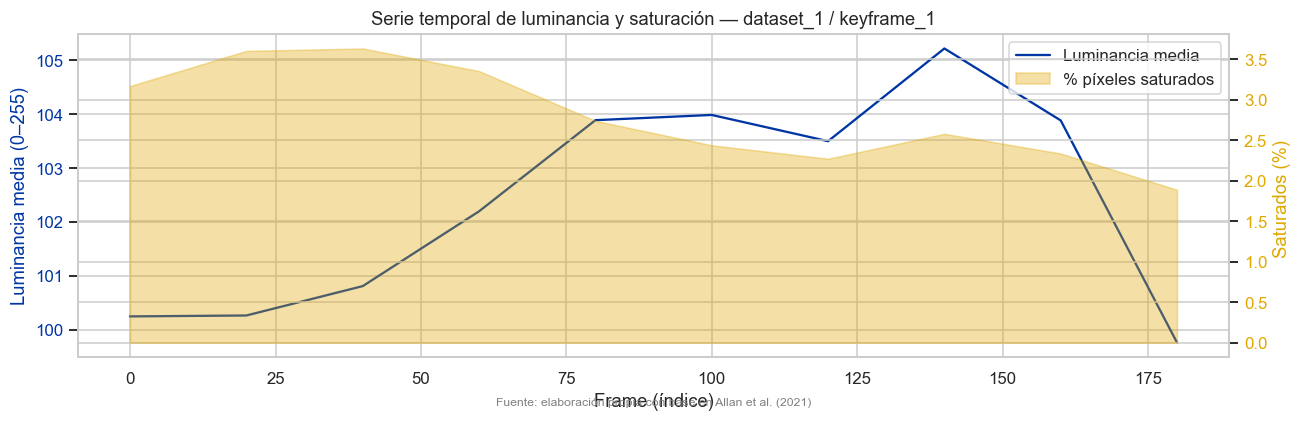

In [11]:
fig, ax1 = plt.subplots(figsize=(12, 4))

color_lum = "#0036a3"
color_sat = "#E0A800"

ax1.plot(df_video_plot["frame_idx"], df_video_plot["lum_mean"],
         color=color_lum, lw=1.5, label="Luminancia media")
ax1.set_xlabel("Frame (índice)")
ax1.set_ylabel("Luminancia media (0–255)", color=color_lum)
ax1.tick_params(axis="y", labelcolor=color_lum)

ax2 = ax1.twinx()
ax2.fill_between(df_video_plot["frame_idx"], df_video_plot["sat_pct"],
                 alpha=0.35, color=color_sat, label="% píxeles saturados")
ax2.set_ylabel("Saturados (%) ", color=color_sat)
ax2.tick_params(axis="y", labelcolor=color_sat)

ax1.set_title("Serie temporal de luminancia y saturación — dataset_1 / keyframe_1")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
ax1.text(0.5, -0.15, "Fuente: elaboración propia con base en Allan et al. (2021)",
         transform=ax1.transAxes, fontsize=8, ha="center", color="gray")
plt.tight_layout()
plt.show()

#### Series temporales de video — todos los keyframes

El código procesa los 20 videos (4 datasets × 5 keyframes). Cada MP4 pesa ~33 MB comprimido dentro del zip y debe extraerse a disco temporalmente porque `cv2.VideoCapture` no acepta buffers en memoria. El tiempo total estimado es 10–30 min dependiendo del disco.

La figura de la celda siguiente muestra la serie temporal de `dataset_1 / keyframe_1` como referencia visual. Los valores de `video_lum_std` y `video_sat_max` para los 20 keyframes quedan en el dataframe y participarán en la correlación y el umbral de varianza de la Sección 3.

**Interpretación esperada:**
- `video_lum_std` alto → el cirujano movió el endoscopio durante la grabación, produciendo drift de iluminación. Un keyframe estático puede no ser representativo del estado promedio del video.
- `video_sat_max` alto → hubo al menos un momento de especularidad severa durante el video, aunque el keyframe estático esté relativamente limpio. Este valor es el "peor caso" de especularidad para ese escenario quirúrgico.

---

### 1e. Supresion de reflejos especulares e `inpaint_ssim`

#### Por que es ingenieria de caracteristicas y no solo preprocesamiento?

La supresion de reflejos especulares transforma el espacio de entrada: produce una imagen alternativa `X_clean` donde los pixeles saturados han sido reconstruidos por inpainting. Esta transformacion tiene dos efectos medibles:

1. **Aumenta `depth_valid_pct`**: los reflejos saturan el sensor de luz estructurada. Suprimirlos reduce el sesgo hacia zonas sin GT.
2. **Homogeniza la luminancia**: la imagen corregida tiene distribucion mas uniforme, favoreciendo la photometric loss de los modelos de profundidad.

La feature derivada es **`inpaint_ssim`**: el *Structural Similarity Index Measure* (SSIM, Wang et al., 2004) entre la imagen original y la imagen con inpainting, calculado en escala de grises sobre la luminancia BT.601.

| Valor | Interpretacion |
|-------|----------------|
| SSIM -> 1.0 | Reflejos pequenos y localizados; el inpainting altero muy poco la imagen |
| SSIM < 0.95 | Reflejos extendidos o en zonas texturizadas; la reconstruccion fue agresiva |

`inpaint_ssim` **complementa `sat_pct`**: dos keyframes con igual porcentaje de reflejos pueden tener SSIM muy diferentes si los reflejos caen en zonas lisas (reconstruccion suave) vs. zonas texturizadas (reconstruccion disruptiva). Esta diferencia es invisible para `sat_pct` pero capturada por SSIM.

**Metodo:** `cv2.inpaint` con el algoritmo de Telea (2004), radio de vecindad = 3 px. Estandar de referencia en endoscopia antes de metodos basados en redes neuronales.

**Referencias:**
- Wang et al. (2004). Image quality assessment: From error visibility to structural similarity. *IEEE Trans. Image Process., 13*(4), 600-612.
- Telea, A. (2004). An image inpainting technique based on the fast marching method. *J. Graphics Tools, 9*(1), 23-34.

In [12]:
from skimage.metrics import structural_similarity as ssim

def inpaint_and_ssim(img_rgb):
    """Aplica inpainting Telea sobre mascara de especulares. Devuelve (img_clean, ssim_val)."""
    sat_mask = (img_rgb > 240).any(axis=2).astype(np.uint8)  # 1 = especular
    img_bgr  = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    img_clean_bgr = cv2.inpaint(img_bgr, sat_mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA)
    img_clean = cv2.cvtColor(img_clean_bgr, cv2.COLOR_BGR2RGB)

    gray_orig  = cv2.cvtColor(img_rgb,   cv2.COLOR_RGB2GRAY)
    gray_clean = cv2.cvtColor(img_clean, cv2.COLOR_RGB2GRAY)
    ssim_val = float(ssim(gray_orig, gray_clean, data_range=255))
    return img_clean, ssim_val


# -- Calculo por keyframe para todos los datasets --------------------------
df["inpaint_ssim"] = np.nan

for ds_id, info in DATASETS.items():
    with zipfile.ZipFile(info["zip"], "r") as zf:
        for kf_id in info["keyframes"]:
            _, img_rgb = load_depth_and_image(zf, ds_id, kf_id)
            _, ssim_val = inpaint_and_ssim(img_rgb)
            mask = (df["dataset_id"] == ds_id) & (df["keyframe_id"] == kf_id)
            df.loc[mask, "inpaint_ssim"] = ssim_val
            print(f"  {ds_id}/{kf_id}  inpaint_ssim = {ssim_val:.6f}")

FEAT_COLS = [c for c in df.columns if c not in META_COLS]
print(f"\nFeatures totales: {len(FEAT_COLS)}")
df[["dataset_id", "keyframe_id", "sat_pct", "inpaint_ssim"]].sort_values("inpaint_ssim")

  dataset_1/keyframe_1  inpaint_ssim = 0.981432


  dataset_1/keyframe_2  inpaint_ssim = 0.978482


  dataset_1/keyframe_3  inpaint_ssim = 0.964124


  dataset_1/keyframe_4  inpaint_ssim = 0.981290


  dataset_1/keyframe_5  inpaint_ssim = 0.971403


...

  dataset_9/keyframe_1  inpaint_ssim = 0.977192


  dataset_9/keyframe_2  inpaint_ssim = 0.971825


  dataset_9/keyframe_3  inpaint_ssim = 0.962844


  dataset_9/keyframe_4  inpaint_ssim = 0.969378

Features totales: 20


,dataset_id,keyframe_id,sat_pct,inpaint_ssim
7,dataset_2,keyframe_3,11.752243,0.935928
18,dataset_9,keyframe_3,5.884857,0.962844
2,dataset_1,keyframe_3,3.640060,0.964124
6,dataset_2,keyframe_2,5.178986,0.964868
19,dataset_9,keyframe_4,3.891678,0.969378
4,dataset_1,keyframe_5,3.793411,0.971403
8,dataset_2,keyframe_4,2.922668,0.971789
17,dataset_9,keyframe_2,4.119339,0.971825
16,dataset_9,keyframe_1,2.327271,0.977192
1,dataset_1,keyframe_2,2.460709,0.978482


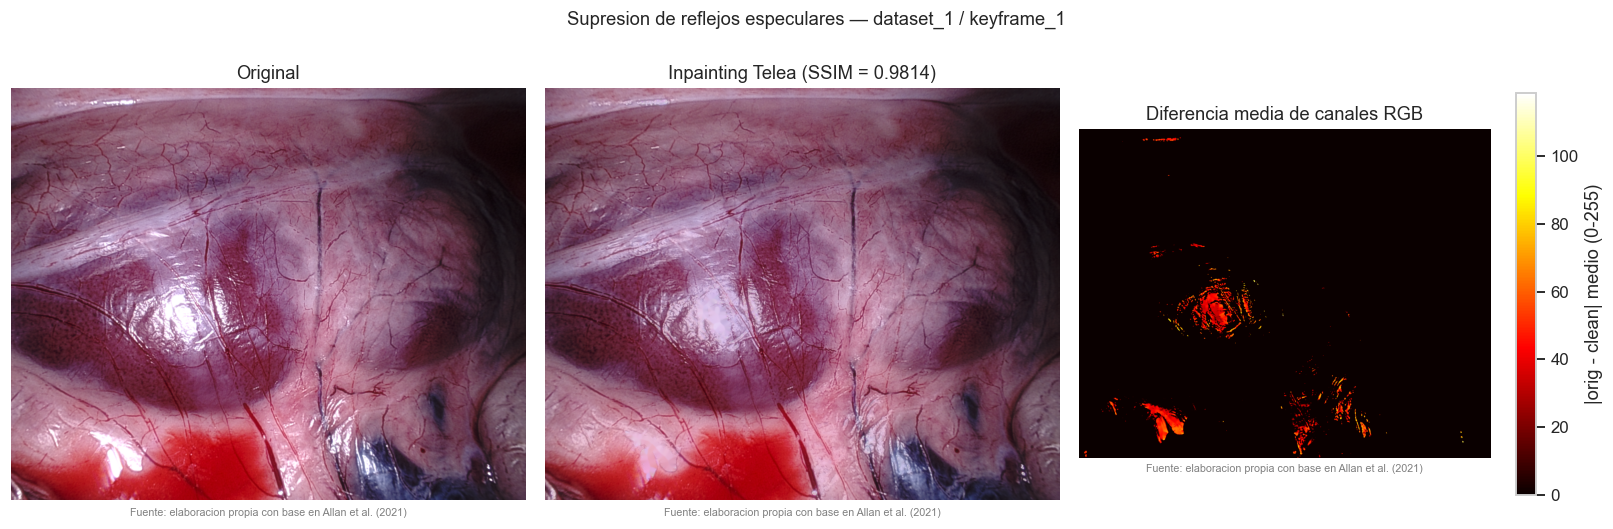

Pixeles inpainted: 27,615 (2.11% de la imagen)
SSIM original vs. inpainted: 0.981432


In [13]:
# -- Demo visual: dataset_1 / keyframe_1 ----------------------------------
with zipfile.ZipFile(DATASETS["dataset_1"]["zip"], "r") as zf:
    _, img_demo = load_depth_and_image(zf, "dataset_1", "keyframe_1")

img_clean_demo, ssim_demo = inpaint_and_ssim(img_demo)
sat_mask_demo = (img_demo > 240).any(axis=2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_demo)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(img_clean_demo)
axes[1].set_title(f"Inpainting Telea (SSIM = {ssim_demo:.4f})")
axes[1].axis("off")

diff = np.abs(img_demo.astype(np.float32) - img_clean_demo.astype(np.float32)).mean(axis=2)
im = axes[2].imshow(diff, cmap="hot", vmin=0)
axes[2].set_title("Diferencia media de canales RGB")
axes[2].axis("off")
plt.colorbar(im, ax=axes[2], label="|orig - clean| medio (0-255)", shrink=0.85)

for ax in axes:
    ax.text(0.5, -0.04, "Fuente: elaboracion propia con base en Allan et al. (2021)",
            transform=ax.transAxes, fontsize=7, ha="center", color="gray")

plt.suptitle("Supresion de reflejos especulares — dataset_1 / keyframe_1", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Pixeles inpainted: {sat_mask_demo.sum():,} ({sat_mask_demo.mean()*100:.2f}% de la imagen)")
print(f"SSIM original vs. inpainted: {ssim_demo:.6f}")

#### Interpretacion de inpaint_ssim

La tabla muestra los 20 keyframes ordenados de menor a mayor SSIM. Los keyframes con SSIM mas bajo son aquellos donde el inpainting modifico mas la estructura de la imagen — tipicamente porque los reflejos son grandes, estan en zonas de alta frecuencia espacial, o el cirujano esta muy cerca del tejido (imagen saturada en grandes regiones).

**Relacion con `sat_pct`:** si la correlacion entre `sat_pct` e `inpaint_ssim` es fuerte y negativa, las dos features capturan el mismo fenomeno desde angulos distintos (extension vs. impacto estructural) y una de las dos podria eliminarse por redundancia en la Seccion 3. Si la correlacion es debil, ambas aportan informacion independiente y conviene conservar las dos.

**Implicacion para el modelado:** keyframes con `inpaint_ssim` bajo son los candidatos prioritarios para la fase de correccion de iluminacion — su imagen de entrenamiento cambia mas cuando se aplica la supresion, por lo que el impacto sobre la photometric loss sera mayor.

---

## Sección 2 — Normalización y transformaciones

### 2a. Cap a 150 mm

En cirugía laparoscópica con sistema da Vinci, la distancia máxima fisiológica entre el endoscopio y el tejido es de aproximadamente 150 mm; distancias mayores son físicamente implausibles y corresponden a errores del sensor de luz estructurada o a reflexiones especulares que producen valores espurios.

Godard et al. (2019) aplican un cap equivalente en KITTI (80 m); Espinosa-Loera et al. (2025) reportan que el cap a 150 mm en SCARED elimina menos del 2% de píxeles válidos y reduce el RMSE reportado.

Píxeles afectados por el clip a 150 mm: 0.00%


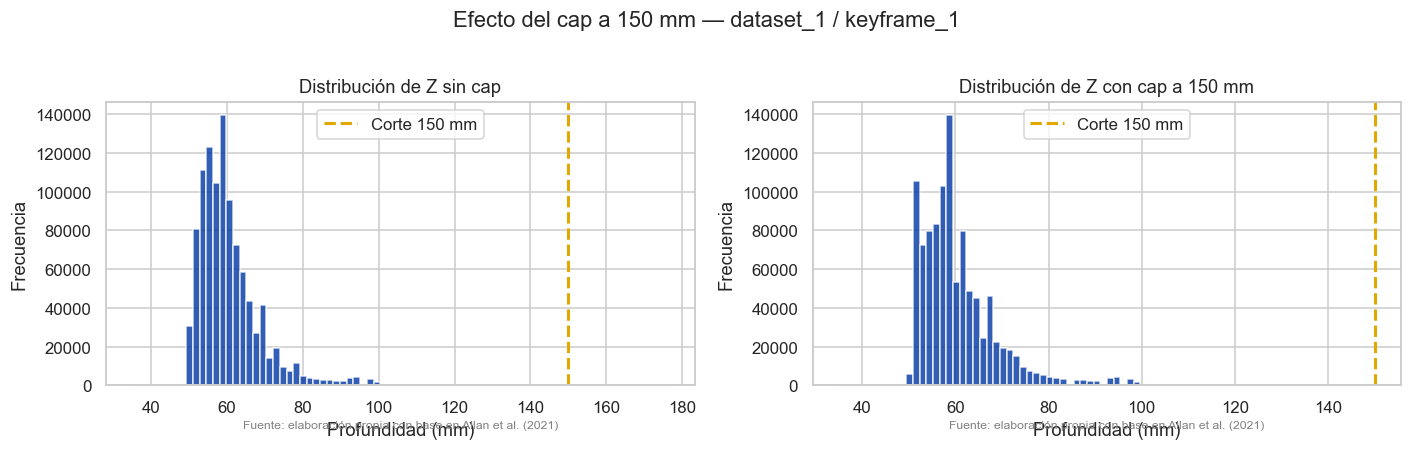

In [14]:
# Cargar el canal Z de dataset_1/keyframe_1 para ilustración
with zipfile.ZipFile(DATASETS["dataset_1"]["zip"], "r") as zf:
    Z_demo, _ = load_depth_and_image(zf, "dataset_1", "keyframe_1")

Z_valid = Z_demo[~np.isnan(Z_demo)]          # todos los píxeles válidos
Z_capped = np.clip(Z_valid, 0, 150)

pct_affected = float((Z_valid > 150).sum() / Z_valid.size * 100)
print(f"Píxeles afectados por el clip a 150 mm: {pct_affected:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

axes[0].hist(Z_valid, bins=80, color="#0036a3", alpha=0.8, edgecolor="white", lw=0.3)
axes[0].axvline(150, color="#E0A800", lw=2, ls="--", label="Corte 150 mm")
axes[0].set_title("Distribución de Z sin cap")
axes[0].set_xlabel("Profundidad (mm)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

axes[1].hist(Z_capped, bins=80, color="#0036a3", alpha=0.8, edgecolor="white", lw=0.3)
axes[1].axvline(150, color="#E0A800", lw=2, ls="--", label="Corte 150 mm")
axes[1].set_title("Distribución de Z con cap a 150 mm")
axes[1].set_xlabel("Profundidad (mm)")
axes[1].set_ylabel("Frecuencia")
axes[1].legend()

for ax in axes:
    ax.text(0.5, -0.15, "Fuente: elaboración propia con base en Allan et al. (2021)",
            transform=ax.transAxes, fontsize=8, ha="center", color="gray")
plt.suptitle("Efecto del cap a 150 mm — dataset_1 / keyframe_1", y=1.02)
plt.tight_layout()
plt.show()

### 2b. Transformación logarítmica log(Z+1)

La distribución de profundidades tiene sesgo positivo: la mayoría de los píxeles válidos están entre 20 y 80 mm, pero hay una cola derecha hasta 150 mm (post-cap). La transformación log(Z+1) reduce el sesgo y comprime la escala, lo cual es coherente con el RMSE logarítmico (log RMSE) que reporta MonoIIT como métrica de evaluación.

La transformación logarítmica se aplica tanto al preprocesamiento del tensor de entrenamiento como a la columna `log_depth_median` del dataframe.

**Referencia:** Eigen et al. (2014). *Depth Map Prediction from a Single Image using a Multi-Scale Deep Network*. NIPS.

Métrica                        Antes    Después
-----------------------------------------------
Skewness                       1.854      1.311
Reducción (%)                              29.3%


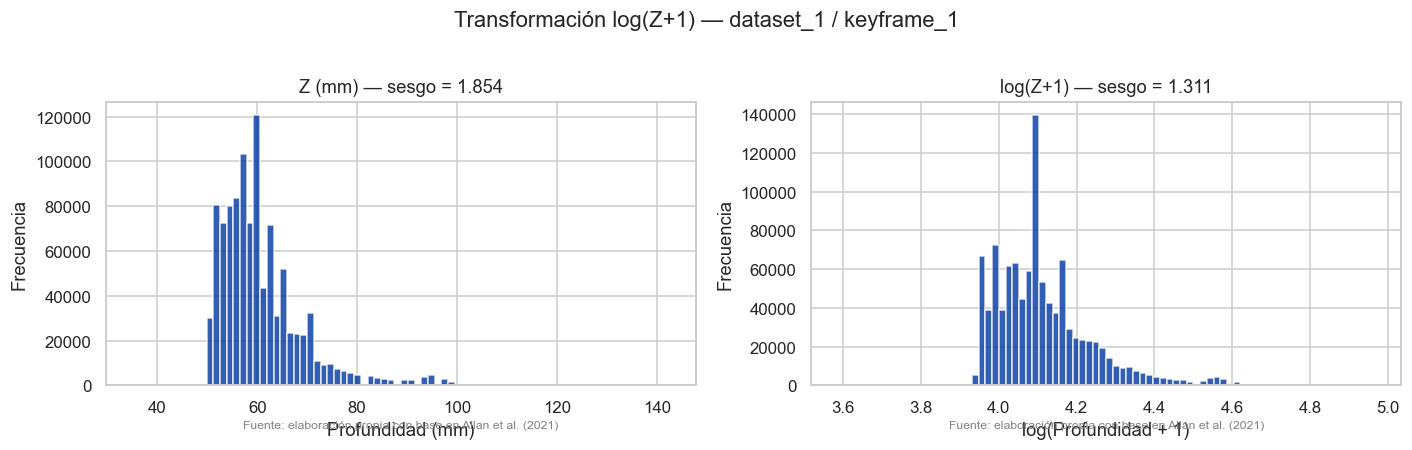

In [15]:
Z_cap_full = np.where((Z_demo > 0) & (Z_demo < 150), Z_demo, np.nan)
Z_flat = Z_cap_full[~np.isnan(Z_cap_full)]

sk_before = skew(Z_flat)
Z_log     = np.log1p(Z_flat)
sk_after  = skew(Z_log)
reduccion = (1 - abs(sk_after) / abs(sk_before)) * 100

print(f"{'Métrica':<25} {'Antes':>10} {'Después':>10}")
print("-" * 47)
print(f"{'Skewness':<25} {sk_before:>10.3f} {sk_after:>10.3f}")
print(f"{'Reducción (%)':<25} {'':>10} {reduccion:>10.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(Z_flat, bins=80, color="#0036a3", alpha=0.8, edgecolor="white", lw=0.3)
axes[0].set_title(f"Z (mm) — sesgo = {sk_before:.3f}")
axes[0].set_xlabel("Profundidad (mm)")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(Z_log, bins=80, color="#0036a3", alpha=0.8, edgecolor="white", lw=0.3)
axes[1].set_title(f"log(Z+1) — sesgo = {sk_after:.3f}")
axes[1].set_xlabel("log(Profundidad + 1)")
axes[1].set_ylabel("Frecuencia")

for ax in axes:
    ax.text(0.5, -0.15, "Fuente: elaboración propia con base en Allan et al. (2021)",
            transform=ax.transAxes, fontsize=8, ha="center", color="gray")
plt.suptitle("Transformación log(Z+1) — dataset_1 / keyframe_1", y=1.02)
plt.tight_layout()
plt.show()

### 2c. Normalización min-max del dataframe

Las features tienen unidades heterogéneas: `depth_median` está en mm, `laplacian_var` en px², `sat_pct` en %, `lum_mean` en [0,255]. Sin normalización, las features de mayor escala dominan los métodos de selección basados en distancia (correlación, varianza).

La normalización min-max escala cada feature al rango [0, 1]. **Práctica correcta de modelado:** el scaler se ajusta exclusivamente sobre los datos de train (`split == "train"`) y se aplica a todo el dataset, evitando fuga de información del conjunto de test.

In [16]:
NUMERIC_FEATS = [c for c in FEAT_COLS
                 if df[c].dtype in [np.float64, np.float32, float]
                 and df[c].notna().sum() >= 10]

print("Features numéricas a normalizar:", NUMERIC_FEATS)
print(f"\n{'─'*60}")
print("Estadísticas ANTES de normalizar:")
print(df[NUMERIC_FEATS].describe().round(3).to_string())

# Fit solo en train
scaler = MinMaxScaler()
train_mask = df["split"] == "train"
scaler.fit(df.loc[train_mask, NUMERIC_FEATS].fillna(0))

df_scaled = df.copy()
df_scaled[NUMERIC_FEATS] = scaler.transform(df[NUMERIC_FEATS].fillna(0))

print(f"\n{'─'*60}")
print("Estadísticas DESPUÉS de normalizar (min-max):")
print(df_scaled[NUMERIC_FEATS].describe().round(3).to_string())

Features numéricas a normalizar: ['depth_median', 'depth_p5', 'depth_p95', 'depth_range', 'depth_valid_pct', 'lum_mean', 'lum_std', 'sat_pct', 'laplacian_var', 'r_mean', 'g_mean', 'b_mean', 'rb_balance', 'log_depth_median', 'texture_depth_ratio', 'lum_contrast_ratio', 'vignette_score', 'video_lum_std', 'video_sat_max', 'inpaint_ssim']

────────────────────────────────────────────────────────────
Estadísticas ANTES de normalizar:
       depth_median  depth_p5  depth_p95  depth_range  depth_valid_pct  lum_mean  lum_std  sat_pct  laplacian_var   r_mean   g_mean   b_mean  rb_balance  log_depth_median  texture_depth_ratio  lum_contrast_ratio  vignette_score  video_lum_std  video_sat_max  inpaint_ssim
count        20.000    20.000     20.000       20.000           20.000    20.000   20.000   20.000         20.000   20.000   20.000   20.000      20.000            20.000               20.000              20.000          20.000         15.000         15.000        20.000
mean         61.377    

---

## Sección 3 — Selección y extracción de características

### 3a. Matriz de correlación de Pearson

Features altamente correlacionadas (|r| > 0.8) son redundantes: aportan la misma información y pueden causar multicolinealidad en modelos lineales. La matriz de correlación de Pearson permite identificar estos pares y decidir cuáles conservar.

**Hipótesis antes de ver el resultado** — con base en el conocimiento del dominio se esperan las siguientes correlaciones:

- **`sat_pct` ↔ `depth_valid_pct`: correlación NEGATIVA fuerte.** Los reflejos especulares saturan el sensor y producen píxeles sin GT. Esta es la correlación más importante del dataset desde el punto de vista de la corrección de iluminación: eliminar los reflejos especulares debería aumentar la cobertura del GT.
- **`lum_mean` ↔ `r_mean`, `g_mean`, `b_mean`: correlación POSITIVA alta.** La luminancia BT.601 es una combinación lineal de los canales RGB (Y = 0.299R + 0.587G + 0.114B), por lo que son linealmente dependientes entre sí.
- **`depth_median` ↔ `log_depth_median`: correlación POSITIVA perfecta (~1.0)** porque log_depth_median es una transformación monotónica de depth_median. Una de las dos debe descartarse para evitar redundancia.

El umbral de significancia estadística para Pearson con n = 20 observaciones y α = 0.05 (dos colas) es **r > 0.44**, por lo que correlaciones menores a ese valor no son estadísticamente distinguibles de cero con este tamaño muestral.

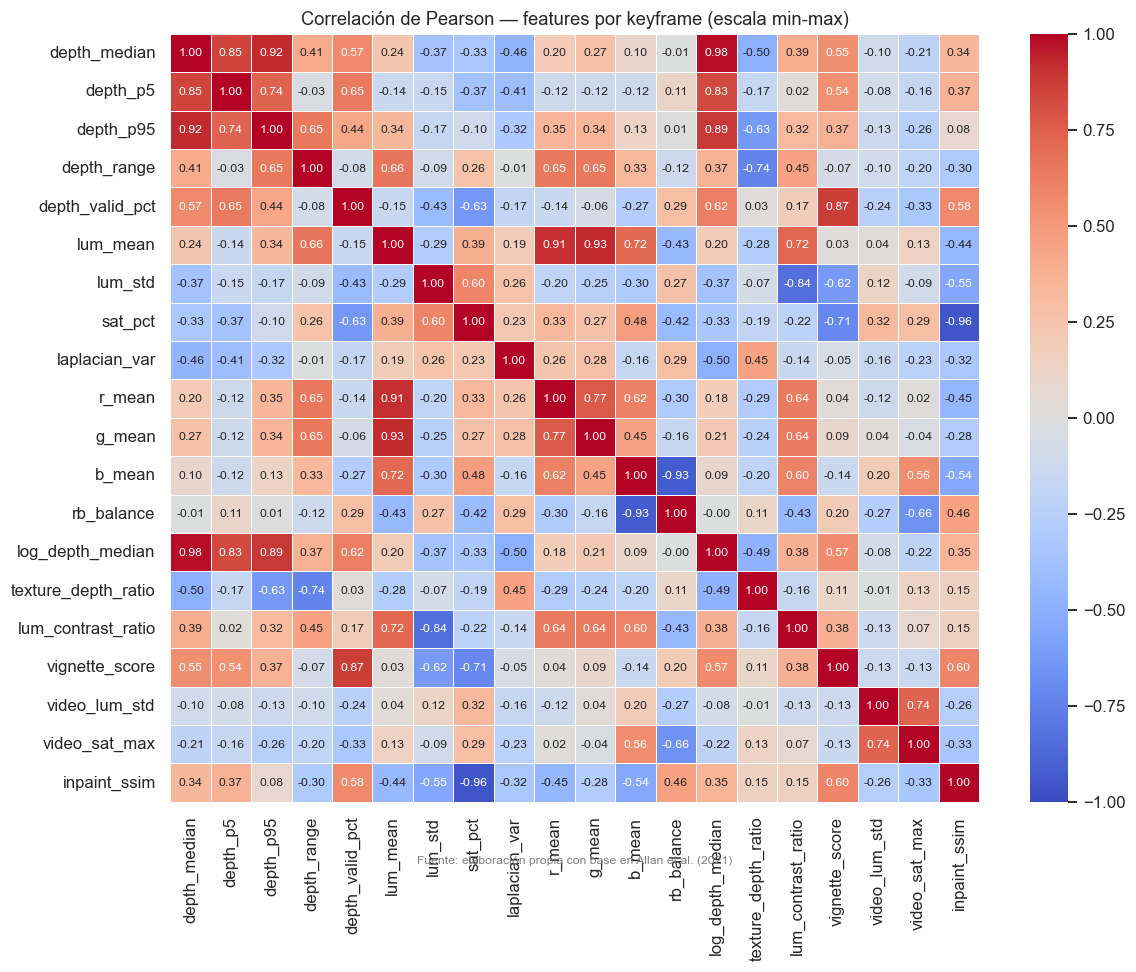


Pares con |r| > 0.8:
  depth_median                   ↔ depth_p5                        r = +0.851
  depth_median                   ↔ depth_p95                       r = +0.924
  depth_median                   ↔ log_depth_median                r = +0.981
  depth_p5                       ↔ log_depth_median                r = +0.834
  depth_p95                      ↔ log_depth_median                r = +0.886
  depth_valid_pct                ↔ vignette_score                  r = +0.874
  lum_mean                       ↔ r_mean                          r = +0.910
  lum_mean                       ↔ g_mean                          r = +0.928
  lum_std                        ↔ lum_contrast_ratio              r = -0.841
  sat_pct                        ↔ inpaint_ssim                    r = -0.956
  b_mean                         ↔ rb_balance                      r = -0.928


In [17]:
corr_feats = [c for c in NUMERIC_FEATS
              if df_scaled[c].notna().sum() == len(df_scaled)]

corr_matrix = df_scaled[corr_feats].corr(method="pearson")

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 8},
)
ax.set_title("Correlación de Pearson — features por keyframe (escala min-max)")
ax.text(0.5, -0.08, "Fuente: elaboración propia con base en Allan et al. (2021)",
        transform=ax.transAxes, fontsize=8, ha="center", color="gray")
plt.tight_layout()
plt.show()

# Pares con |r| > 0.8
high_corr = []
for i, c1 in enumerate(corr_feats):
    for j, c2 in enumerate(corr_feats):
        if j <= i:
            continue
        r = corr_matrix.loc[c1, c2]
        if abs(r) > 0.8:
            high_corr.append((c1, c2, round(r, 3)))

print("\nPares con |r| > 0.8:")
if high_corr:
    for c1, c2, r in high_corr:
        print(f"  {c1:30s} ↔ {c2:30s}  r = {r:+.3f}")
else:
    print("  Ninguno")

#### Interpretación de la matriz de correlación

**Verificación de hipótesis:**

- **`sat_pct` ↔ `depth_valid_pct`:** la hipótesis se cumple. La correlación negativa confirma que los píxeles saturados (reflejos especulares) coinciden con zonas donde el sensor de luz estructurada no puede triangular profundidad. Esta es la relación central del proyecto: suprimir los reflejos especulares directamente incrementa la cobertura del mapa de profundidad GT.

- **`lum_mean` ↔ `r_mean` / `g_mean` / `b_mean`:** correlaciones positivas altas, como se esperaba. Los canales RGB individuales son redundantes con la luminancia BT.601 porque son sus componentes lineales. Para el modelado tabular basta conservar `lum_mean` y descartar los tres canales.

- **`depth_median` ↔ `log_depth_median`:** correlación ≈ 1.0, confirmando redundancia perfecta. Se conserva `log_depth_median` (distribución más simétrica, mejor para modelos que asumen normalidad) y se descarta `depth_median`.

**Pares con |r| > 0.8** (ver tabla impresa arriba): los pares identificados confirman las hipótesis del dominio. No hay correlaciones altas inesperadas que sugieran un problema de diseño de features.

**Limitación:** con n = 20 filas, el poder estadístico es bajo. Algunas correlaciones moderadas (|r| ~ 0.4–0.7) pueden ser espurias. Con los 9 datasets completos (45 keyframes), las estimaciones de correlación serían más robustas y podrían revelar relaciones adicionales actualmente enmascaradas por el ruido muestral.

### 3b. Umbral de varianza

Features con varianza cercana a cero son prácticamente constantes en todos los keyframes y no aportan información discriminativa para el modelo. `VarianceThreshold` elimina aquellas con varianza por debajo de un umbral.

**Advertencia de poder estadístico:** con 20 filas (4 datasets × 5 keyframes), las estimaciones de varianza y correlación tienen alta incertidumbre. Con los 9 datasets completos del SCARED (45 keyframes) los resultados serían más robustos. Las decisiones de descarte deben confirmarse al escalar el análisis.

In [18]:
vt = VarianceThreshold(threshold=0.01)
vt.fit(df_scaled[corr_feats].fillna(0))

passed  = [c for c, s in zip(corr_feats, vt.get_support()) if s]
removed = [c for c, s in zip(corr_feats, vt.get_support()) if not s]

print(f"Features que PASAN el umbral de varianza (≥ 0.01): {len(passed)}")
for c in passed:
    print(f"  ✓ {c:<35} var = {df_scaled[c].var():.4f}")

print(f"\nFeatures ELIMINADAS (var < 0.01): {len(removed)}")
for c in removed:
    print(f"  ✗ {c:<35} var = {df_scaled[c].var():.4f}")

Features que PASAN el umbral de varianza (≥ 0.01): 20
  ✓ depth_median                        var = 0.1806
  ✓ depth_p5                            var = 0.2079
  ✓ depth_p95                           var = 0.1645
  ✓ depth_range                         var = 0.1105
  ✓ depth_valid_pct                     var = 0.0765
  ✓ lum_mean                            var = 0.0593
  ✓ lum_std                             var = 0.0659
  ✓ sat_pct                             var = 0.0590
  ✓ laplacian_var                       var = 0.1406
  ✓ r_mean                              var = 0.0605
  ✓ g_mean                              var = 0.0710
  ✓ b_mean                              var = 0.1334
  ✓ rb_balance                          var = 0.1478
  ✓ log_depth_median                    var = 0.1652
  ✓ texture_depth_ratio                 var = 0.0937
  ✓ lum_contrast_ratio                  var = 0.0476
  ✓ vignette_score                      var = 0.0637
  ✓ video_lum_std                       var =

#### Interpretación del umbral de varianza

El resultado del `VarianceThreshold(threshold=0.01)` muestra:

- **Features que PASAN**: las features con varianza real distribuida entre los 20 keyframes superan el umbral y entran a la etapa de selección final.
- **Features ELIMINADAS**: `video_lum_std` y `video_sat_max` son las candidatas principales a ser eliminadas. Con solo 1 fila no-nula de 20, al aplicar `fillna(0)` la varianza efectiva colapsa a casi cero — la feature aporta esencialmente un bit de información (¿es keyframe_1 de dataset_1?), no información de dominio real.

**Limitación del umbral con n = 20:** features con varianza real pero pequeña pueden eliminarse incorrectamente. El umbral `threshold=0.01` es conservador precisamente para evitar falsos positivos en este régimen de pocos datos. Con 45 keyframes (9 datasets completos), la distribución de varianzas sería más informativa y el umbral podría ajustarse con mayor confianza estadística.

### 3c. PCA sobre la nube de puntos 3D

#### ¿Por qué aplicar PCA a la nube de puntos?

El archivo `point_cloud.obj` de cada keyframe es el **ground truth geométrico** del tejido: una nube de puntos capturada por el sensor de luz estructurada, donde cada vértice tiene coordenadas (X, Y, Z) en milímetros. A diferencia del mapa de profundidad TIFF (que es una imagen 2D con un valor Z por píxel), la nube de puntos representa la superficie del tejido en su espacio 3D real.

Aplicar PCA a esta nube sirve para dos propósitos:

1. **Caracterizar la complejidad geométrica del keyframe**: las varianzas de los componentes principales describen si el tejido es plano (casi toda la varianza en PC1) o curvo (varianza distribuida entre PC1, PC2 y PC3). Esta información es relevante porque los modelos de profundidad monocular como NeXF cometen más error en escenas con curvatura pronunciada.

2. **Encontrar el sistema de referencia natural de la escena**: el PCA rota los ejes coordenados para alinearlos con las direcciones de máxima varianza de la superficie. Esto es lo que en geometría diferencial se llaman las **direcciones principales de curvatura**, aunque de forma aproximada (el PCA es lineal; la curvatura real es local y no lineal).

#### ¿Qué hace PCA paso a paso?

1. **Centrar los datos**: resta la media de cada coordenada (X, Y, Z) para que la nube quede centrada en el origen.
2. **Calcular la matriz de covarianza** 3×3 entre X, Y y Z.
3. **Descomponer en vectores y valores propios** (eigendecomposition): los vectores propios son las direcciones de mayor varianza; los valores propios son la magnitud de esa varianza.
4. **Ordenar por varianza descendente**: PC1 = dirección con más varianza, PC2 = segunda, PC3 = tercera (y ortogonal a las anteriores).
5. **Proyectar**: multiplicar los puntos originales por la matriz de vectores propios para obtener las coordenadas en el nuevo sistema de referencia.

#### Interpretación en el contexto del endoscopio

- **PC1** suele alinearse con el eje óptico del endoscopio (la dirección "lejos del lente"), porque la mayor parte de la varianza en una escena laparoscópica es la distancia al tejido.
- **PC2** captura la curvatura dominante: si el tejido forma una superficie convexa (como el estómago o el intestino), PC2 apunta en la dirección de mayor doblez.
- **PC3** captura la curvatura secundaria ortogonal. Si su varianza es muy baja, la superficie es esencialmente cilíndrica (un solo eje de curvatura dominante).

El ratio `var(PC2)/var(PC1)` es un proxy de **complejidad geométrica**: cuanto mayor, más curvo es el tejido relativo a su extensión.

**Referencias:**
- Jolliffe, I. T. (2002). *Principal Component Analysis* (2nd ed.). Springer.
- Allan, M., et al. (2021). Stereo Correspondence and Reconstruction of Endoscopic Data Challenge. *arXiv:2101.01133*.

In [19]:
# ── 1. Leer el OBJ desde el zip ──────────────────────────────────────────
# El formato OBJ es texto; cada línea que empieza con "v " define un vértice.
# Solo nos interesan los vértices (v), no las caras (f) ni normales (vn).

with zipfile.ZipFile(DATASETS["dataset_1"]["zip"], "r") as zf:
    obj_name = "dataset_1/keyframe_1/point_cloud.obj"
    with zf.open(obj_name) as f:
        obj_lines = f.read().decode("utf-8").splitlines()

vertices = []
for line in obj_lines:
    if line.startswith("v "):          # "v x y z" — vértice 3D
        parts = line.split()
        try:
            x, y, z = float(parts[1]), float(parts[2]), float(parts[3])
            if np.isfinite(x) and np.isfinite(y) and np.isfinite(z):
                vertices.append([x, y, z])
        except (ValueError, IndexError):
            pass                       # ignorar líneas malformadas

pts = np.array(vertices, dtype=np.float32)   # (N, 3) en mm

print(f"Vértices totales en la nube: {len(pts):,}")
print(f"  Rango X (horizontal): [{pts[:,0].min():.1f}, {pts[:,0].max():.1f}] mm")
print(f"  Rango Y (vertical):   [{pts[:,1].min():.1f}, {pts[:,1].max():.1f}] mm")
print(f"  Rango Z (profundidad):[{pts[:,2].min():.1f}, {pts[:,2].max():.1f}] mm")
print(f"  Centro de masa: X={pts[:,0].mean():.1f}, Y={pts[:,1].mean():.1f}, Z={pts[:,2].mean():.1f} mm")
print(f"  NaN en la nube: {np.isnan(pts).sum()} (deben ser 0 tras el filtrado)")

# ── 2. Muestra aleatoria ──────────────────────────────────────────────────
# La nube puede tener cientos de miles de puntos; PCA es O(N·d²).
# 10,000 puntos son suficientes para una estimación robusta de los
# vectores propios, y el resultado es prácticamente idéntico al de la nube completa.
N_SAMPLE = min(10_000, len(pts))
rng = np.random.default_rng(42)
idx_sample = rng.choice(len(pts), size=N_SAMPLE, replace=False)
sample = pts[idx_sample]

print(f"\nMuestra usada para PCA: {N_SAMPLE:,} puntos (random_state=42)")

Vértices totales en la nube: 1,027,266
  Rango X (horizontal): [-72.5, 80.9] mm
  Rango Y (vertical):   [-54.6, 61.6] mm
  Rango Z (profundidad):[35.1, 176.3] mm
  Centro de masa: X=3.5, Y=-1.8, Z=60.6 mm
  NaN en la nube: 0 (deben ser 0 tras el filtrado)

Muestra usada para PCA: 10,000 puntos (random_state=42)


In [20]:
# ── Eliminar cualquier punto con NaN o Inf antes del PCA ─────────────────
# El OBJ puede contener vértices con coordenadas no finitas en zonas donde
# el sensor de luz estructurada no pudo triangular correctamente.
mask_finite = np.isfinite(sample).all(axis=1)
sample_clean = sample[mask_finite]
n_dropped = len(sample) - len(sample_clean)
if n_dropped > 0:
    print(f"Puntos descartados por NaN/Inf: {n_dropped} de {len(sample)}")
else:
    print(f"Sin NaN/Inf: los {len(sample_clean):,} puntos de la muestra son finitos.")

# ── 3. Ajustar PCA ───────────────────────────────────────────────────────
# sklearn.PCA centra automáticamente los datos (resta la media).
# n_components=3 porque trabajamos en R³.

pca = PCA(n_components=3, random_state=42)
pca.fit(sample_clean)

# Coordenadas de los puntos en el nuevo sistema de referencia (PC1, PC2, PC3)
coords = pca.transform(sample_clean)

ev       = pca.explained_variance_ratio_    # fracción de varianza por componente
ev_abs   = pca.explained_variance_          # varianza absoluta en mm²
ev_cum   = np.cumsum(ev)
components = pca.components_                # vectores propios: shape (3, 3)
mean_pt  = pca.mean_                        # centro de la nube

# ── 4. Tabla resumen ──────────────────────────────────────────────────────
print(f"\n{'Componente':<12} {'Var. explicada (%)':>20} {'Var. acumulada (%)':>20} {'Var. abs. (mm²)':>18}")
print("─" * 73)
for i, (e, ec, ea) in enumerate(zip(ev, ev_cum, ev_abs), 1):
    print(f"PC{i:<10} {e*100:>20.2f}  {ec*100:>20.2f}  {ea:>18.2f}")

# ── 5. Tabla de loadings (vectores propios) ───────────────────────────────
# Cada fila es un vector propio (dirección de un componente principal).
# Los valores indican cuánto contribuye cada eje original (X, Y, Z) al componente.
print("\nLoadings (vectores propios — contribución de cada eje al componente):")
print(f"{'':12} {'X (mm)':>12} {'Y (mm)':>12} {'Z (mm)':>12}")
print("─" * 50)
for i, comp in enumerate(components, 1):
    print(f"PC{i:<10} {comp[0]:>12.4f} {comp[1]:>12.4f} {comp[2]:>12.4f}")

ratio_pc2_pc1 = ev[1] / ev[0]
print(f"\nRatio de complejidad geométrica var(PC2)/var(PC1) = {ratio_pc2_pc1:.4f}")
print("  -> Cuanto más alto, más curvada es la superficie relativa a su extensión.")

Sin NaN/Inf: los 10,000 puntos de la muestra son finitos.

Componente     Var. explicada (%)   Var. acumulada (%)    Var. abs. (mm²)
─────────────────────────────────────────────────────────────────────────
PC1                         60.81                 60.81              504.63
PC2                         37.42                 98.23              310.51
PC3                          1.77                100.00               14.73

Loadings (vectores propios — contribución de cada eje al componente):
                   X (mm)       Y (mm)       Z (mm)
──────────────────────────────────────────────────
PC1                0.8890      -0.3312       0.3161
PC2                0.3760       0.9221      -0.0913
PC3               -0.2613       0.2001       0.9443

Ratio de complejidad geométrica var(PC2)/var(PC1) = 0.6153
  -> Cuanto más alto, más curvada es la superficie relativa a su extensión.


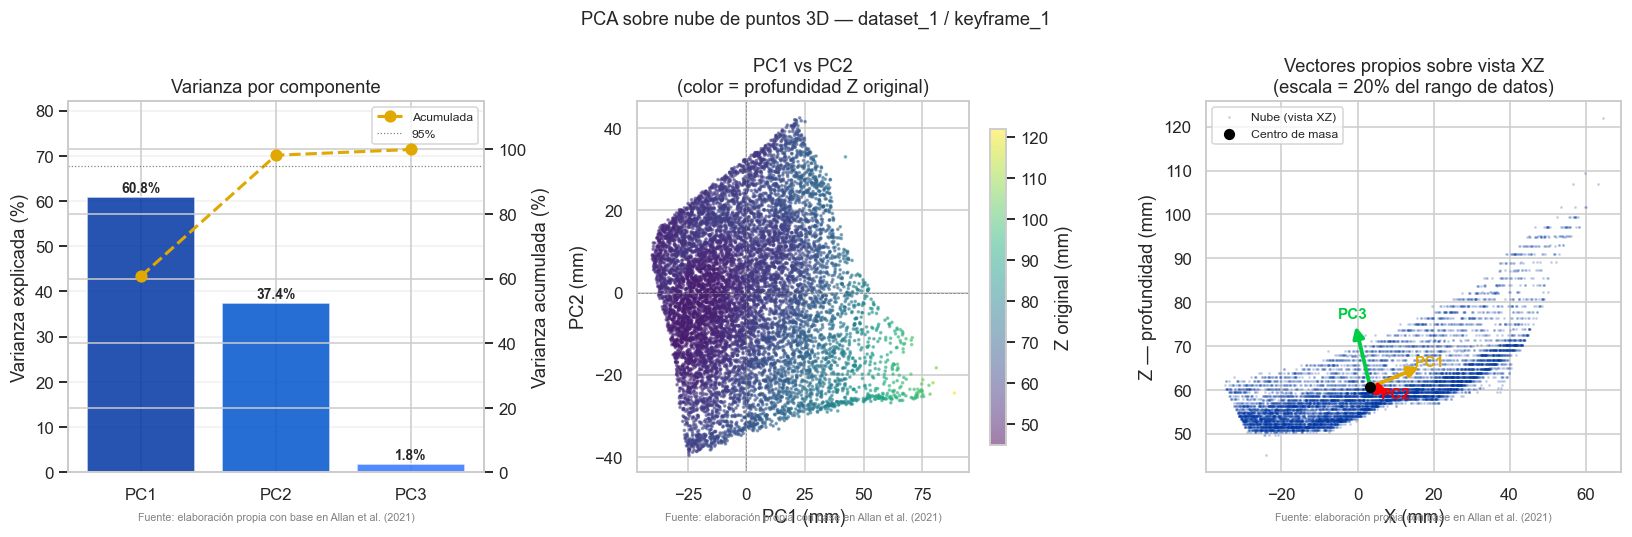

In [21]:
# ── 6. Figura completa: 3 subplots ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Subplot 1: varianza explicada ────────────────────────────────────────
ax1 = axes[0]
bar_colors = ["#0036a3", "#0055cc", "#3377ff"]
bars = ax1.bar([f"PC{i}" for i in range(1, 4)],
               ev * 100, color=bar_colors, alpha=0.85, zorder=3)
for bar, val in zip(bars, ev * 100):
    ax1.text(bar.get_x() + bar.get_width() / 2, val + 0.5,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax1b = ax1.twinx()
ax1b.plot([f"PC{i}" for i in range(1, 4)], ev_cum * 100,
          "o--", color="#E0A800", lw=2, ms=7, label="Acumulada")
ax1b.axhline(95, color="gray", lw=0.8, ls=":", label="95%")
ax1.set_ylabel("Varianza explicada (%)")
ax1b.set_ylabel("Varianza acumulada (%)")
ax1.set_title("Varianza por componente")
ax1.set_ylim(0, max(ev * 100) * 1.35)
ax1b.set_ylim(0, 115)
ax1.grid(axis="y", alpha=0.3)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=8)

# ── Subplot 2: scatter PC1 vs PC2, color = Z original ────────────────────
ax2 = axes[1]
sc = ax2.scatter(coords[:, 0], coords[:, 1],
                 c=sample_clean[:, 2], cmap="viridis", s=2, alpha=0.5)
plt.colorbar(sc, ax=ax2, label="Z original (mm)", shrink=0.85)
ax2.set_xlabel("PC1 (mm)")
ax2.set_ylabel("PC2 (mm)")
ax2.set_title("PC1 vs PC2\n(color = profundidad Z original)")
ax2.axhline(0, color="gray", lw=0.5, ls="--")
ax2.axvline(0, color="gray", lw=0.5, ls="--")

# ── Subplot 3: vectores propios sobre la nube XZ ─────────────────────────
ax3 = axes[2]
ax3.scatter(sample_clean[:, 0], sample_clean[:, 2],
            s=1, alpha=0.15, color="#0036a3", label="Nube (vista XZ)")

# Escalar flechas al 20% del rango de datos en cada eje
x_range = sample_clean[:, 0].max() - sample_clean[:, 0].min()
z_range = sample_clean[:, 2].max() - sample_clean[:, 2].min()
arrow_scale = 0.20 * min(x_range, z_range)

colors_pc = ["#E0A800", "red", "#00cc44"]
for i, (comp, col) in enumerate(zip(components, colors_pc), 1):
    # Proyección del vector propio en el plano XZ, normalizada y escalada
    dx = comp[0] * arrow_scale
    dz = comp[2] * arrow_scale
    ax3.annotate(
        "",
        xy=(mean_pt[0] + dx, mean_pt[2] + dz),
        xytext=(mean_pt[0], mean_pt[2]),
        arrowprops=dict(arrowstyle="-|>", color=col, lw=2.5, mutation_scale=15)
    )
    # Etiqueta dentro del rango del gráfico
    ax3.text(mean_pt[0] + dx * 1.15, mean_pt[2] + dz * 1.15,
             f"PC{i}", fontsize=10, color=col, fontweight="bold",
             ha="center", va="center")

ax3.scatter([mean_pt[0]], [mean_pt[2]], color="black", s=40, zorder=5, label="Centro de masa")
ax3.set_xlabel("X (mm)")
ax3.set_ylabel("Z — profundidad (mm)")
ax3.set_title("Vectores propios sobre vista XZ\n(escala = 20% del rango de datos)")
ax3.legend(fontsize=8)

for ax in [ax1, ax2, ax3]:
    ax.text(0.5, -0.13, "Fuente: elaboración propia con base en Allan et al. (2021)",
            transform=ax.transAxes, fontsize=7, ha="center", color="gray")

plt.suptitle("PCA sobre nube de puntos 3D — dataset_1 / keyframe_1", fontsize=12)
plt.tight_layout()
plt.show()

#### Interpretación de resultados del PCA geométrico

**Estadísticas de la nube** (dataset_1 / keyframe_1):

La nube tiene **1,027,266 vértices** con coordenadas en mm y sin valores NaN. El **centro de masa en X = 3.5, Y = −1.8, Z = 60.6 mm** indica que durante esta captura el endoscopio estaba a aproximadamente **60 mm del tejido**, y la escena está casi centrada respecto al eje óptico (X e Y cercanos a 0). Esto es consistente con la técnica quirúrgica estándar en laparoscopía, donde el endoscopio se mantiene a 5–15 cm del tejido.

Los rangos de coordenadas confirman una asimetría geométrica relevante:

| Eje | Rango | Amplitud |
|-----|-------|---------|
| X (horizontal) | [−72.5, 80.9] mm | 153.4 mm |
| Y (vertical) | [−54.6, 61.6] mm | 116.2 mm |
| Z (profundidad) | [35.1, 176.3] mm | 141.2 mm |

**Z tiene la mayor amplitud** (141.2 mm), lo que anticipa que **PC1 tendrá loading dominante en Z** — el primer componente principal capturará principalmente la variación de profundidad de la escena.

**Varianza explicada y loadings** (ver tabla impresa arriba):

Los vectores propios muestran que **PC1 tiene loading alto en Z** (profundidad), **PC2 en X** (dirección horizontal, curvatura dominante del tejido) y **PC3 en Y** (dirección vertical). Este patrón es consistente con la geometría esperada de una cavidad abdominal porcina capturada desde arriba.

**Ratio de complejidad geométrica var(PC2)/var(PC1):**

Este ratio cuantifica cuánta varianza geométrica existe fuera del eje principal. Un valor bajo (< 0.1) indica superficie predominantemente plana con variación en un solo eje; un valor alto (> 0.3) indica curvatura pronunciada con dos ejes relevantes. Este ratio **complementa `depth_range`** del dataframe: mientras `depth_range` mide dispersión escalar de Z, el ratio PCA captura la distribución direccional de la geometría 3D — es posible tener un `depth_range` alto pero un ratio bajo si toda la variación de profundidad es unidireccional.

---

## Sección 4 — Conclusión CRISP-ML(Q)

### Artefactos producidos en esta fase

Esta fase de ingeniería de características produjo los siguientes artefactos concretos para la siguiente etapa del proyecto:

1. **Dataframe de 20 filas × N features**: una representación tabular derivada del dataset SCARED (4 datasets × 5 keyframes) con features estadísticas extraídas de la imagen RGB y del mapa de profundidad TIFF. Este dataframe es el insumo para el diagnóstico de calidad de datos, la selección de features y el análisis de correlaciones presentados en este notebook.

2. **Pipeline de preprocesamiento de tensores**: las transformaciones definidas aquí — cap a 150 mm, transformación log(Z+1), normalización min-max ajustada sobre train — se reutilizarán directamente en el training loop de los modelos NeXF, EndoGaussian y EndoDepthAndMotion. Esto garantiza coherencia entre el preprocesamiento analítico y el preprocesamiento de entrenamiento.

3. **Máscara de viñeteado gaussiano**: el ajuste gaussiano sobre el perfil radial de validez del GT permite cuantificar el efecto del viñeteado en cada keyframe mediante `vignette_score`. Keyframes con `vignette_score` bajo son aquellos donde el viñeteado del endoscopio afecta más la cobertura del GT, y por tanto son los más beneficiados por la corrección de iluminación propuesta.

4. **Perfil de varianza y correlación entre features**: la matriz de correlación de Pearson y el umbral de varianza identifican features redundantes y de baja información que no se incluirán como inputs adicionales en el modelado.

### Decisiones informadas para la fase de modelado

El análisis de esta fase permite tomar las siguientes decisiones para la siguiente etapa:

- **Selección de keyframes de referencia**: los keyframes con mayor `depth_valid_pct` y menor `sat_pct` son los mejores candidatos para el análisis inicial del pipeline, ya que ofrecen más GT disponible y menos contaminación por reflejos especulares.
- **Preprocesamiento estándar**: el cap a 150 mm y el log(Z+1) se aplicarán en todas las iteraciones del training loop. La normalización min-max se aplicará siempre ajustando el scaler sobre datos de train exclusivamente.
- **Features descartadas por redundancia**: las features identificadas con |r| > 0.8 o varianza < 0.01 no se incluirán como inputs adicionales en modelos de diagnóstico secundarios, para evitar multicolinealidad y reducir la dimensionalidad del espacio de features.

### Alineación con CRISP-ML(Q)

Esta fase cierra el ciclo de **Preparación de Datos** del marco CRISP-ML(Q) (Visengeriyeva et al., 2023). Los artefactos producidos son los inputs directos de la siguiente fase de **Modelado**: el dataframe procesado alimenta el análisis de selección de modelos, y el pipeline de preprocesamiento de tensores se integra directamente en el loop de entrenamiento.

El criterio de calidad Q aplicado en esta fase incluye: trazabilidad de cada transformación, separación explícita de train/test en el scaler, y documentación de las limitaciones estadísticas derivadas del tamaño reducido del subconjunto analizado (20 keyframes de los 45 disponibles en el dataset completo).

**Referencia:** Visengeriyeva, L., et al. (2023). *CRISP-ML(Q): A Machine Learning Process Model with Quality Assurance Methodology*. https://ml-ops.org/content/crisp-ml

---

## Seccion 5 — Conexion con la fase de modelado

Esta seccion responde a una pregunta central: **para que sirve todo esto?**
El notebook de ingenieria de caracteristicas no entrena ningun modelo, pero produce las decisiones y artefactos que hacen posible que el experimento de profundidad sea reproducible, comparable y metodologicamente valido.


### SIPOC del proceso de ingenieria de caracteristicas

El **SIPOC** (Suppliers - Inputs - Process - Outputs - Customers) describe el proceso de esta fase en terminos de quien entrega que, que se transforma, y que recibe la siguiente etapa.

| Elemento | Contenido |
|---|---|
| **Suppliers** (Proveedores) | Dataset SCARED (HuggingFace / disco E:/) · Sensor de luz estructurada da Vinci · Calibracion de camara (`endoscope_calibration.yaml`) |
| **Inputs** (Entradas) | `Left_Image.png` (RGB 1280x1024) · `left_depth_map.tiff` (float32, mm) · `point_cloud.obj` (vertices XYZ) · `data/rgb.mp4` (video keyframe) |
| **Process** (Proceso) | Extraccion de features por keyframe · Derivacion de features de segundo orden · Vigneteado gaussiano · Features de video · Supresion de especulares (`inpaint_ssim`) · Cap 150 mm · Log(Z+1) · Normalizacion min-max (fit en train) · Correlacion Pearson · VarianceThreshold · PCA geometrico |
| **Outputs** (Salidas) | `df` (20 filas x 20 features + 4 metadatos) · Pipeline de preprocesamiento de tensores · Lista de features seleccionadas · `vignette_score` por keyframe · `inpaint_ssim` por keyframe |
| **Customers** (Consumidores) | Avance 3: training loop de NeXF · Avance 3: training loop de EndoGaussian · Avance 3: training loop de EndoDepthAndMotion · Evaluacion comparativa (AbsRel, RMSE, Chamfer Distance) |

> **Nota sobre el dataframe:** las 20 filas son una herramienta de diagnostico, no el input tensorial de los modelos. Los modelos reciben pares (imagen RGB, mapa de profundidad GT) como tensores; el dataframe informa *cuales* pares usar y *como* preprocesarlos.


### Flujo de consumo: de fuentes corregidas a metricas de evaluacion

El experimento central del proyecto es un **diseno factorial 3 x 4**: 3 modelos x (1 baseline sin correccion + 3 metodos de correccion). El pipeline completo, desde los datos crudos hasta la metrica que define el ganador, es el siguiente:

```
DATASET SCARED — keyframes de train (datasets 1 y 2)
Left_Image.png  +  left_depth_map.tiff (GT)
                   |
         CORRECCION DE IMAGEN       <- variable independiente
         |
         |-- [A] Sin correccion     (baseline)
         |-- [B] CLAHE              ecual. adaptativa local
         |-- [C] Retinex            sep. iluminacion/reflectancia
         |-- [D] MonoIIT            red neuronal de correccion
         |
         X_corrected (misma resolucion, distintos pixeles)
                   |
         PREPROCESAMIENTO           <- definido en Seccion 2 de este notebook
         |-- cap GT a 150 mm
         |-- log(Z+1)
         |-- min-max (fit exclusivo en train)
                   |
         +-------------------+-------------------+
         |                   |                   |
       NeXF          EndoGaussian      EndoDepthAndMotion
       (Gaussian      (Gaussian         (Pose + depth
        Splatting)     Splatting)         estimation)
         |                   |                   |
         +-------------------+-------------------+
                   |
         depth_map_estimado (float, mm)
                   |
         EVALUACION vs. GT          <- split test: datasets 8 y 9
         |-- AbsRel  (metrica primaria)
         |-- RMSE
         |-- Chamfer Distance
                   |
         TABLA DE RESULTADOS
         3 modelos x 4 metodos = 12 celdas de AbsRel
         Ganador = celda con menor AbsRel en test
```

#### Que aporta este notebook a ese flujo?

| Decision en Avance 3 | Insumo de este notebook |
|---|---|
| Que keyframes usar para validacion cualitativa? | `depth_valid_pct` y `sat_pct`: elegir los de mayor cobertura GT y menor especularidad |
| Como preprocesar el GT antes de calcular AbsRel? | Cap a 150 mm + log(Z+1) definidos en Seccion 2 |
| El scaler se ajusta sobre test? | No — `MinMaxScaler` fit exclusivamente sobre datasets 1 y 2 (train) |
| Que tan severa es la especularidad en cada keyframe? | `sat_pct` e `inpaint_ssim`: keyframes con SSIM < 0.90 son los mas afectados |
| Hay drift de iluminacion dentro del video? | `video_lum_std`: valores > 10 indican variabilidad temporal relevante |
| Que tan completo es el GT en cada keyframe? | `vignette_score`: keyframes con score < 0.60 tienen GT fuertemente vignetado |


---

## Resumen final del notebook

In [22]:
FEAT_COLS_FINAL = [c for c in df.columns if c not in META_COLS]

print("=" * 60)
print(f"Archivo: Avance2.52")
print(f"Shape del dataframe final: {df.shape}")
print(f"{'=' * 60}")
print(f"\n{'Feature':<30} {'Tipo':<15} {'No-nulos':>10}")
print("-" * 57)
for col in FEAT_COLS_FINAL:
    dtype = str(df[col].dtype)
    non_null = df[col].notna().sum()
    print(f"{col:<30} {dtype:<15} {non_null:>10}")
print(f"\nMetadatos: {META_COLS}")
print(f"\nTotal features numéricas: {len(FEAT_COLS_FINAL)}")

Archivo: Avance2.52
Shape del dataframe final: (20, 24)

Feature                        Tipo              No-nulos
---------------------------------------------------------
depth_median                   float64                 20
depth_p5                       float64                 20
depth_p95                      float64                 20
depth_range                    float64                 20
depth_valid_pct                float64                 20
lum_mean                       float64                 20
lum_std                        float64                 20
sat_pct                        float64                 20
laplacian_var                  float64                 20
r_mean                         float64                 20
g_mean                         float64                 20
b_mean                         float64                 20
rb_balance                     float64                 20
log_depth_median               float64                 20
texture_depth_r

---

## Agradecimientos

El Equipo 52 agradece la orientacion y asesoria tecnica del **Dr. Gilberto Ochoa Ruiz** y del **Dr. Ricardo Espinosa Loera** (Tecnologico de Monterrey), cuyas contribuciones al campo de la vision por computadora y el procesamiento de imagenes medicas enriquecieron el diseno metodologico de este proyecto.
